## Create Respiration Feature Matrix of Social Interactions (Sniffing)

## Mice and Recs to Drop:
- 1.1 & 1.2 from Aim1
- All Recs without Boris (3_6)

In [52]:
import os
import sys
from pathlib import Path
import h5py
import re

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exists in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper functions didn't exist in working directory, resolving and adding to sys.path")

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.pipeline import Pipeline

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# All the functions used to load, clean, and verify respiration and BORIS data
from resp_helper_functions import *

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper functions didn't exist in working directory, resolving and adding to sys.path


### AIM1 Paths (Rank CM Respiration and H5s)

In [53]:
# AIM1 Paths
aim1_h5_dir = Path(r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_h5\baseline_cagemate_interactions_h5_outputs")
aim1_boris_dir = Path(r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_boris\baseline csv")

# BLA paths
bla_cm_h5_dir = Path(r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\BLA_ChR_resp_pilot1 (SS)\BLA_resp_ChR_cm_hc\h5_outputs")
bla_cm_boris_dir = Path(r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\BLA_ChR_resp_pilot1 (SS)\BLA_resp_ChR_cm_boris")

print(f"Aim1 H5 files   : {len(list(aim1_h5_dir.glob('*.h5')))}")
print(f"Aim1 BORIS files: {len(list(aim1_boris_dir.glob('*.csv')))}")
print(f"BLA H5 files    : {len(list(bla_cm_h5_dir.glob('*.h5')))}")
print(f"BLA BORIS files : {len(list(bla_cm_boris_dir.glob('*.csv')))}")

Aim1 H5 files   : 9
Aim1 BORIS files: 10
BLA H5 files    : 25
BLA BORIS files : 32


## Configuration Setup Over

---

## Inspection of H5 Metadata, Respiration, & Behavior

### Mice and Recs to Drop:
- 1.1 & 1.2 from Aim1 (Fighting)
- All Recs without Boris (3_6)

### Important Boris/Behavior & H5 respiration File Notes:
#### Boris Notes:
- Aim1: exclude the bad duplicate `CM_s4_8_sub4_7_20250623.csv` (missing session time); keep the timestamped export for that session
- BLA outlier: a few sessions have **two** exports for the same H5 — `VT_SA` (subject) and `VT_CM` (social agent). See `bla_boris_sa_cm_pairs` above the catalog build
- **BORIS naming** `CM_s{...}_{date}_{time}.1.csv` or `.1_VT.csv` | various tags (`VT_CM`, `VT_SA`, `BORIS_SS`, …)

#### H5 Respiration Notes:
- Aim1 respiration signal key is `resp` (20 kHz; metadata in `resp_metadata`)
- BLA respiration has two signals:
    - Cleaned, downsampled respiration @ 100 Hz: `resp_clean/signal` (+ time in `resp_clean/time`)
    - Raw Trodes analog @ 20 kHz: `analog/{session_stem}.analog_ECU_Ain1` — read the `voltage` field, e.g. `f["analog"][key][:]["voltage"]` (find key with `"ECU_Ain1"` in the name)
- For feature extraction, use `load_rank_resp_signal_interactions()` — prefers raw 20 kHz, preprocesses to 400 Hz; falls back to `resp_clean` only if raw is missing
- Use `load_rank_resp_signal_interactions()` to load respiration turns 20KHz -> 400Hz Sampling Rate
- **H5 naming** `CM_s{mouse}_{rank}{partner}_{date}_{time}_merged.h5` | `{sub}_{par}_{role}_cm_{...}_{date}_{time}.h5` |


## H5 Inspection

In [54]:
def print_h5_structure(h5_path, max_datasets=20):
    """Print groups, datasets, and attrs for one H5 file."""
    print(h5_path.name)
    with h5py.File(h5_path, "r") as f:
        if f.attrs:
            print("root attrs:", dict(f.attrs))

        n_printed = 0
        def _walk(name, obj):
            nonlocal n_printed
            if n_printed >= max_datasets:
                return
            if isinstance(obj, h5py.Dataset):
                print(f"  DATASET {name}: shape={obj.shape}, dtype={obj.dtype}")
                if obj.attrs:
                    print(f"    attrs: {dict(obj.attrs)}")
                n_printed += 1
            elif isinstance(obj, h5py.Group):
                print(f"  GROUP   {name}/")
                if obj.attrs:
                    print(f"    attrs: {dict(obj.attrs)}")
                else:
                    print(f"{obj.name} does not have attributes")

        f.visititems(_walk)

# One example from each cohort
EXAMPLE_AIM1_H5 = sorted(aim1_h5_dir.glob("*.h5"))[0]
EXAMPLE_BLA_H5  = sorted(bla_cm_h5_dir.glob("*.h5"))[0]

print("AIM1 COHORT EXAMPLE H5:")
print(('-')*50)
print_h5_structure(EXAMPLE_AIM1_H5)

print("\nBLA COHORT EXAMPLE H5:")
print(('-')*50)
print_h5_structure(EXAMPLE_BLA_H5)



AIM1 COHORT EXAMPLE H5:
--------------------------------------------------
CM_s1_1_d1_2_20250623_111352_merged.h5
  GROUP   ekg_metadata/
/ekg_metadata does not have attributes
  GROUP   metadata/
/metadata does not have attributes
  DATASET resp: shape=(12252312,), dtype=float32
  GROUP   resp_metadata/
    attrs: {'byte_order': 'little endian', 'channel': 'analog_ECU_Ain1', 'duration_sec': np.float64(612.6156), 'duration_sec_from_ekg_sr': np.float64(612.6156), 'duration_sec_hardcoded_20k': np.float64(612.6156), 'num_samples': np.int64(12252312), 'sampling_frequency': np.float64(20000.0), 'start_time': np.float64(nan), 'units': 'volts'}

BLA COHORT EXAMPLE H5:
--------------------------------------------------
1_1_i_cm_1_2_d_20260106_134350.h5
  GROUP   analog/
/analog does not have attributes
  DATASET analog/1_1_d_cm_1_2_i_20260106_134350.analog_ECU_Ain1: shape=(12205353,), dtype=[('voltage', '<i2')]
    attrs: {'accelerometer': '-1', 'autosettle': '-1', 'byte_order': 'little endian

Checking if Loading Raw Signal works with Resp Helper

In [55]:
for p in sorted(bla_cm_h5_dir.glob("*.h5")):
    with h5py.File(p, "r") as f:
        signal, time, fs, meta = load_rank_resp_signal_interactions(p)
        print(f"  {p.name}: resp_clean/signal n={len(time)}, fs_from_time={fs:.1f} Hz")

  1_1_i_cm_1_2_d_20260106_134350.h5: resp_clean/signal n=244108, fs_from_time=400.0 Hz
  1_1_i_cm_1_3_s_20260107_163611.h5: resp_clean/signal n=245743, fs_from_time=400.0 Hz
  1_2_d_cm_1_3_s_20260108_114416.h5: resp_clean/signal n=241419, fs_from_time=400.0 Hz
  1_3_s_1_2_d_20260107_165340.h5: resp_clean/signal n=243525, fs_from_time=400.0 Hz
  1_3_s_cm_1_1_i_20260106_122823.h5: resp_clean/signal n=241862, fs_from_time=400.0 Hz
  2_1_d_cm_2.3_i_20260106_105109.h5: resp_clean/signal n=241419, fs_from_time=400.0 Hz
  2_1_d_cm_2_2_s_20260108_112426.h5: resp_clean/signal n=245826, fs_from_time=400.0 Hz
  2_2_s_cm_2_1_d_20260108_120453.h5: resp_clean/signal n=243747, fs_from_time=400.0 Hz
  2_2_s_cm_2_1_d_20260108_120453.rec.h5: resp_clean/signal n=243747, fs_from_time=400.0 Hz
  2_2_s_cm_2_3_i_20260106_132549.h5: resp_clean/signal n=245410, fs_from_time=400.0 Hz
  3_1_i_cm_3_2_d_20260106_115157.h5: resp_clean/signal n=242223, fs_from_time=400.0 Hz
  3_1_i_cm_3_3_s_20260107_123230.h5: resp_

## Respiration Inspection (Resp Rate Frequency Distribution)

Helper Functions

In [56]:
# --- Instantaneous breathing-rate inspection (Aim1 + BLA) ---

TARGET_FS = 400
PERMISSIVE_MAX_HZ = 25
GET_SNIFF_MAX_HZ = 12


def load_session_signal(h5_path, cohort=None, target_rate=TARGET_FS):
    """Load resp using the same loader as build_feature_matrix."""
    return load_rank_resp_signal_interactions(
        str(h5_path), target_rate=target_rate, prefer_raw=True, verbose=False
    )


def inst_rates_from_onsets(onset_times):
    """IBI -> instantaneous Hz from consecutive onsets."""
    onset_times = np.asarray(onset_times, dtype=float)
    if len(onset_times) < 2:
        return np.array([])
    ibi = np.diff(onset_times)
    ibi = ibi[(ibi > 0) & np.isfinite(ibi)]
    if len(ibi) == 0:
        return np.array([])
    return 1.0 / ibi


def inst_rates_from_peaks(signal, time, fs, max_hz=PERMISSIVE_MAX_HZ):
    """Permissive peak-based IBI (upper bound on detectable rate = max_hz)."""
    distance = max(1, int(fs / max_hz))
    peaks, _ = find_peaks(signal, distance=distance)
    if len(peaks) < 2:
        return np.array([])
    return inst_rates_from_onsets(time[peaks])

In [57]:
# def inspect_session_rates(h5_path, cohort, target_rate=TARGET_FS):
#     """BreathMetrics inhale onsets + permissive peaks; optional 100 vs 400 for BLA."""
#     signal, time, fs, load_meta = load_session_signal(h5_path, cohort, target_rate=target_rate)
#     if signal is None:
#         return None

#     row = {
#         "file": h5_path.name,
#         "cohort": cohort,
#         "loader_fs": fs,
#         "resampled": load_meta.get("resampled") if load_meta else np.nan,
#         "loader_original_fs": load_meta.get("original_fs") if load_meta else np.nan,
#         "duration_s": float(time[-1] - time[0]) if len(time) > 1 else np.nan,
#     }

#     bm = fit_bm_session(signal, fs, data_type="rodentAirflow")
#     if bm is not None and hasattr(bm, "inhaleOnsets") and len(bm.inhaleOnsets) >= 2:
#         bm_times = time[np.asarray(bm.inhaleOnsets, dtype=int)]
#         bm_rates = inst_rates_from_onsets(bm_times)
#     else:
#         bm_rates = np.array([])

#     peak_rates = inst_rates_from_peaks(signal, time, fs, max_hz=PERMISSIVE_MAX_HZ)
#     capped_rates = inst_rates_from_peaks(signal, time, fs, max_hz=GET_SNIFF_MAX_HZ)

#     for prefix, rates in [
#         ("bm_inhale", bm_rates),
#         ("peaks_25hz", peak_rates),
#         ("peaks_12hz_cap", capped_rates),
#     ]:
#         if len(rates):
#             row[f"{prefix}_median"] = float(np.nanmedian(rates))
#             row[f"{prefix}_p95"] = float(np.nanpercentile(rates, 95))
#             row[f"{prefix}_p99"] = float(np.nanpercentile(rates, 99))
#             row[f"{prefix}_max"] = float(np.nanmax(rates))
#             row[f"{prefix}_pct_gt_12"] = float(np.mean(rates > 12) * 100)
#             row[f"{prefix}_pct_gt_15"] = float(np.mean(rates > 15) * 100)
#         else:
#             for k in ["median", "p95", "p99", "max", "pct_gt_12", "pct_gt_15"]:
#                 row[f"{prefix}_{k}"] = np.nan

#     return row, bm_rates, peak_rates


# rate_rows = []
# all_bm_rates = {"Aim1": [], "BLA": []}

# sessions = (
#     [("Aim1", p) for p in sorted(aim1_h5_dir.glob("*.h5"))]
#     + [("BLA", p) for p in sorted(bla_cm_h5_dir.glob("*.h5"))]
# )

# for cohort, h5_path in sessions:
#     out = inspect_session_rates(h5_path, cohort, target_rate=TARGET_FS)
#     if out is None:
#         continue
#     row, bm_rates, peak_rates = out
#     rate_rows.append(row)
#     all_bm_rates[cohort].extend(bm_rates)

# rate_summary_df = pd.DataFrame(rate_rows)

# fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
# for ax, cohort in zip(axes, ["Aim1", "BLA"]):
#     rates = np.asarray(all_bm_rates[cohort])
#     if len(rates) == 0:
#         ax.set_title(f"{cohort} — no BM rates")
#         continue
#     ax.hist(rates, bins=80, range=(0, 17.5), color="steelblue", alpha=0.85, edgecolor="white")
#     ax.set_xlim(0, 17.5)
#     ax.set_xlabel("Instantaneous rate from BM inhale IBIs (Hz)")
#     ax.set_ylabel("Count")
#     ax.set_title(f"{cohort} (pooled, n={len(rates):,} IBIs)")

# plt.tight_layout()
# plt.show()

## Behavior Inspection


### BORIS labels (raw files)


### Loading/Building Behavior

In [58]:
# Session-aligned BORIS loading (keeps all exports; excludes bad Aim1 duplicate by name)
resp_paths_interactions, boris_paths_interactions, _bla_rank_map_eda, _bla_sa_cm_pairs_eda = build_interaction_boris_catalog(
    aim1_h5_dir,
    aim1_boris_dir,
    bla_cm_h5_dir,
    bla_cm_boris_dir,
    aim1_skip_boris_stems={"CM_s3_6_sub3_5_20250623_174348"},
)

behavior_files = pd.DataFrame()
for trial_key, boris_path in boris_paths_interactions.items():
    cohort = "Aim1" if trial_key.startswith("AIM1") else "BLA"
    try:
        cleaned_behaviors = load_clean_boris(boris_path, subject_only=False)
        if cleaned_behaviors.empty:
            continue
        cleaned_behaviors["source_file"] = trial_key
        cleaned_behaviors["cohort"] = cohort
        cleaned_behaviors["h5_path"] = resp_paths_interactions[trial_key]
        cleaned_behaviors["boris_path"] = boris_path
        behavior_files = pd.concat([behavior_files, cleaned_behaviors], ignore_index=True)
    except Exception as e:
        print(f"Error processing {trial_key} ({boris_path}): {e}")

print(
    f"Loaded {behavior_files['source_file'].nunique()} sessions "
    f"({behavior_files.groupby('cohort')['source_file'].nunique().to_dict()})"
)
behavior_files.head()

  → Excluding Aim1 BORIS: CM_s4_8_sub4_7_20250623.csv
  → Aim1 multiple BORIS exports for one session; using CM_s1_2_sub1_1_20250623_133932.1.csv; also found: ['CM_s1_2_sub1_1_20250623_133932.1_VT.csv']
  ⚠️ No matching BORIS for CM_s3_5_d3_6_20250623_170708_merged.h5 (stem=CM_s3_5_d3_6_20250623_170708)
  ⚠️ Skipping empty BORIS stem: CM_s3_6_sub3_5_20250623_174348
  ⚠️ No matching BLA .h5 for BORIS 1_3_2_s_1_2_d_20260107_165340.1_boris_AJ_with_image_indices_with_image_indices.csv (key=('1_3', '1_2', '20260107', '165340'))


Loaded 38 sessions ({'Aim1': 7, 'BLA': 31})


,Behavior,Initiator,Start,Stop,Duration,source_file,cohort,h5_path,boris_path
0,facial sniffing,social_agent,9.167,9.567,0.400,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...
1,facial sniffing,subject,9.233,9.567,0.334,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...
2,facial sniffing,social_agent,17.867,18.700,0.833,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...
3,facial sniffing,subject,18.200,18.700,0.500,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...
4,facial sniffing,social_agent,24.267,24.700,0.433,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...


In [59]:
behavior_files['source_file'].unique()

array(['AIM1cm_1_1_1_2_20250623_111352', 'AIM1cm_1_2_1_1_20250623_133932',
       'AIM1cm_2_3_2_4_20250623_151153', 'AIM1cm_2_4_2_3_20250623_143348',
       'AIM1cm_3_5_3_6_20250623_160001', 'AIM1cm_4_7_4_8_20250623_193718',
       'AIM1cm_4_8_4_7_20250623_182649',
       'BLAcm_1_1_1_2_20260106_134350_BORIS_SS',
       'BLAcm_1_1_1_3_20260107_163611_VT_CM',
       'BLAcm_1_1_1_3_20260107_163611_VT_SA',
       'BLAcm_1_2_1_3_20260108_114416_VT_CM',
       'BLAcm_1_2_1_3_20260108_114416_VT_SA',
       'BLAcm_1_3_1_1_20260106_122823_boris_AJ_with_image_indices',
       'BLAcm_2_1_2_2_20260108_112426_VT_CM',
       'BLAcm_2_1_2_3_20260106_105109_BORIS_SS',
       'BLAcm_2_1_2_2_20260108_112426_VT_SA',
       'BLAcm_2_2_2_1_20260108_120453_VT_CM',
       'BLAcm_2_2_2_3_20260106_132549_boris_AJ_with_image_indices',
       'BLAcm_2_2_2_1_20260108_120453_VT_SA',
       'BLAcm_3_1_3_2_20260106_115157_BORIS_SS',
       'BLAcm_3_1_3_3_20260107_123230_BORIS_SS',
       'BLAcm_3_2_3_3_20260107_140

### Dropping sniffing behavior row with > 20 seconds. One 400 Sec Behavior Exists

In [60]:
# List of keywords associated with sniffing behaviors
sniffing_keywords = ["sniff", "sniffing"]

# Filter for only sniffing behaviors (case insensitive search)
is_sniffing = behavior_files["Behavior"].str.lower().str.contains("|".join(sniffing_keywords))
sniffing_behaviors = behavior_files[is_sniffing].copy()

# ALSO drop sniffing behaviors with Duration < 0.5 seconds
sniffing_behaviors = sniffing_behaviors[sniffing_behaviors["Duration"] >= 0.5].copy()

def extract_subject_agent(recording_name):
    # Look for sequences like _1_1_1_2_
    nums = re.findall(r'_(\d+)', recording_name)
    if len(nums) >= 4:
        subject = f"{nums[0]}-{nums[1]}"
        agent = f"{nums[2]}-{nums[3]}"
        return subject, agent
    # fallback
    return "", ""

# Add 'subject' and 'social_agent' columns with extracted values
sniffing_behaviors[["subject", "social_agent"]] = sniffing_behaviors["source_file"].apply(
    lambda x: pd.Series(extract_subject_agent(x))
)

In [61]:
# Drop 400+ second behavior row from sniffing_behaviors
row_to_drop = sniffing_behaviors[
    (sniffing_behaviors["Behavior"] == "anogenital sniffing") &
    (sniffing_behaviors["Duration"] > 20)
]
if not row_to_drop.empty:
    sniffing_behaviors = sniffing_behaviors.drop(row_to_drop.index)
    print(f"Dropped rows with index: {row_to_drop.index.tolist()} (anogenital sniffing Duration>20s in AIM1cm_2_3_2_4_20250623_151153)")
else:
    print("No 400+ sec anogenital sniffing row found to drop.")

Dropped rows with index: [84, 95, 109, 171] (anogenital sniffing Duration>20s in AIM1cm_2_3_2_4_20250623_151153)


In [62]:
sniffing_behaviors.head()

,Behavior,Initiator,Start,Stop,Duration,source_file,cohort,h5_path,boris_path,subject,social_agent
2,facial sniffing,social_agent,17.867,18.700,0.833,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,1-1,1-2
3,facial sniffing,subject,18.200,18.700,0.500,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,1-1,1-2
16,facial sniffing,social_agent,113.767,114.867,1.100,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,1-1,1-2
28,facial sniffing,subject,196.467,196.967,0.500,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,1-1,1-2
29,body sniffing,subject,218.467,220.233,1.766,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,1-1,1-2


In [63]:
sniffing_behaviors.isna().mean()

Behavior        0.0
Initiator       0.0
Start           0.0
Stop            0.0
Duration        0.0
source_file     0.0
cohort          0.0
h5_path         0.0
boris_path      0.0
subject         0.0
social_agent    0.0
dtype: float64

In [64]:
sniffing_behaviors["Duration"].max()

np.float64(11.599)

In [65]:
AIM1_BEHAVIORS = sniffing_behaviors[sniffing_behaviors["cohort"] == 'Aim1']

In [66]:
AIM1_BEHAVIORS["subject"].nunique()

7

In [67]:
AIM1_BEHAVIORS["subject"].unique()

array(['1-1', '1-2', '2-3', '2-4', '3-5', '4-7', '4-8'], dtype=object)

In [68]:
AIM1_BEHAVIORS["source_file"].unique()

array(['AIM1cm_1_1_1_2_20250623_111352', 'AIM1cm_1_2_1_1_20250623_133932',
       'AIM1cm_2_3_2_4_20250623_151153', 'AIM1cm_2_4_2_3_20250623_143348',
       'AIM1cm_3_5_3_6_20250623_160001', 'AIM1cm_4_7_4_8_20250623_193718',
       'AIM1cm_4_8_4_7_20250623_182649'], dtype=object)

In [69]:
# Analyze how many sniffing behaviors each recording has
# We'll group by 'source_file', 'subject', 'social_agent', and count the behaviors (rows) in each group

sniffing_per_recording = sniffing_behaviors.groupby(['source_file', 'subject', 'social_agent']).size().reset_index(name='n_behaviors')

print("Sniffing behavior counts per recording:")
for _, row in sniffing_per_recording.iterrows():
    print(
        f"Subject: {row['subject']}, Social Agent: {row['social_agent']}, "
        f"Recording: {row['source_file']}, Total Sniffing Behaviors: {row['n_behaviors']}"
    )

Sniffing behavior counts per recording:
Subject: 1-1, Social Agent: 1-2, Recording: AIM1cm_1_1_1_2_20250623_111352, Total Sniffing Behaviors: 18
Subject: 1-2, Social Agent: 1-1, Recording: AIM1cm_1_2_1_1_20250623_133932, Total Sniffing Behaviors: 18
Subject: 2-3, Social Agent: 2-4, Recording: AIM1cm_2_3_2_4_20250623_151153, Total Sniffing Behaviors: 59
Subject: 2-4, Social Agent: 2-3, Recording: AIM1cm_2_4_2_3_20250623_143348, Total Sniffing Behaviors: 67
Subject: 3-5, Social Agent: 3-6, Recording: AIM1cm_3_5_3_6_20250623_160001, Total Sniffing Behaviors: 61
Subject: 4-7, Social Agent: 4-8, Recording: AIM1cm_4_7_4_8_20250623_193718, Total Sniffing Behaviors: 25
Subject: 4-8, Social Agent: 4-7, Recording: AIM1cm_4_8_4_7_20250623_182649, Total Sniffing Behaviors: 65
Subject: 1-1, Social Agent: 1-2, Recording: BLAcm_1_1_1_2_20260106_134350_BORIS_SS, Total Sniffing Behaviors: 77
Subject: 1-1, Social Agent: 1-3, Recording: BLAcm_1_1_1_3_20260107_163611_VT_CM, Total Sniffing Behaviors: 48
Su

### Cutting Out Subjects That Have Imabalanced Behaviors 

In [70]:
# Subject/trial exclusions applied before BreathMetrics (cohort-aware)
exclude_subjects_by_cohort, exclude_trials_upstream, upstream_exclusion_report = build_upstream_exclusion_set(
    sniffing_behaviors,
    imbalance_ratio=0.4,
    # drop_aim1_subjects=["1_1", "1_2"],
    drop_aim1_subjects=None,
    min_sniffs_per_trial=10,
)

print("Imbalanced subject@cohort (>40% spread across recordings):")
for cohort, subj in upstream_exclusion_report["imbalanced_subject_cohorts"]:
    print(f"  {cohort} / {subj}")
print(f"Aim1-only drops: {upstream_exclusion_report['drop_aim1_subjects']}")
print(f"Low-sniff trials (<10 subject bouts): {upstream_exclusion_report['low_sniff_trials']}")
print(f"Excluded subjects by cohort: {upstream_exclusion_report['exclude_subjects_by_cohort']}")

def _subject_excluded_in_cohort(row):
    cohort = row.get("cohort", "Other")
    subj = normalize_subject_id(row["subject"])
    return subj in exclude_subjects_by_cohort.get(cohort, set())

# --- SHOW ALL BEHAVIOR COUNTS FOR EXCLUDED SUBJECTS ---
# Create mask for rows to be dropped
dropped_behaviors = sniffing_behaviors[sniffing_behaviors.apply(_subject_excluded_in_cohort, axis=1)].copy()

# Group and print behaviors for dropped subjects per recording
if not dropped_behaviors.empty:
    dropped_counts = (
        dropped_behaviors
        .groupby(['subject', 'social_agent', 'source_file'])
        .size()
        .reset_index(name='n_behaviors')
    )
    print("\nSniffing behavior counts per recording (EXCLUDED subjects):")
    for _, row in dropped_counts.iterrows():
        print(
            f"Subject: {row['subject']}, Social Agent: {row['social_agent']}, "
            f"Recording: {row['source_file']}, Total Sniffing Behaviors: {row['n_behaviors']}"
        )
else:
    print("\nNo sniffing behaviors dropped by subject exclusion.")

sniffing_behaviors_balanced = sniffing_behaviors[~sniffing_behaviors.apply(_subject_excluded_in_cohort, axis=1)].copy()
print(
    f"\nFiltered sniffing_behaviors from {sniffing_behaviors['subject'].nunique()} "
    f"to {sniffing_behaviors_balanced['subject'].nunique()} unique subject ids "
    f"(cohort-aware exclusion)."
)

Imbalanced subject@cohort (>40% spread across recordings):
  BLA / 2_1
  BLA / 2_2
  BLA / 3_3
  BLA / 5_1
Aim1-only drops: []
Low-sniff trials (<10 subject bouts): ['AIM1cm_1_2_1_1_20250623_133932', 'BLAcm_2_2_2_3_20260106_132549_boris_AJ_with_image_indices', 'BLAcm_3_2_3_3_20260107_140924_boris_AJ_with_image_indices', 'BLAcm_3_3_3_1_20260106_124546_boris_AJ_with_image_indices', 'BLAcm_4_3_4_1_20260107_113120_boris_AJ_with_image_indices', 'BLAcm_6_2_6_3_20260107_154939_boris_AJ_with_image_indices']
Excluded subjects by cohort: {'BLA': ['2_1', '2_2', '3_3', '5_1']}

Sniffing behavior counts per recording (EXCLUDED subjects):
Subject: 2-1, Social Agent: 2-2, Recording: BLAcm_2_1_2_2_20260108_112426_VT_CM, Total Sniffing Behaviors: 55
Subject: 2-1, Social Agent: 2-2, Recording: BLAcm_2_1_2_2_20260108_112426_VT_SA, Total Sniffing Behaviors: 83
Subject: 2-1, Social Agent: 2-3, Recording: BLAcm_2_1_2_3_20260106_105109_BORIS_SS, Total Sniffing Behaviors: 63
Subject: 2-2, Social Agent: 2-1, R

Sniffing Duration Distribution

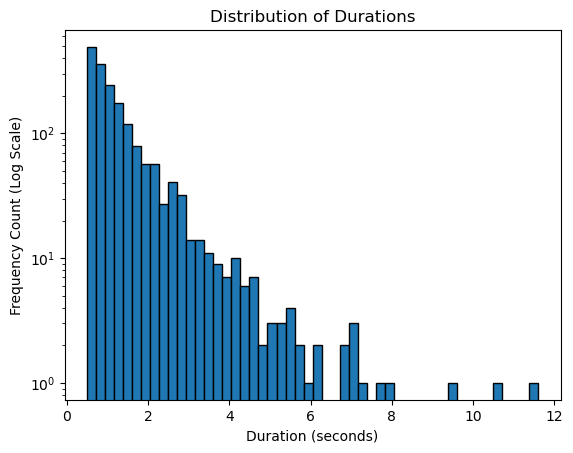

In [71]:
# Plot the distribution using bins
sniffing_behaviors['Duration'].plot(kind='hist', bins=50, edgecolor='black')

# Compress the y-axis so rare events (like 50s) become visible
plt.yscale('log')

plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency Count (Log Scale)')
plt.title('Distribution of Durations')
plt.show()

Median/Mean Total Sniffing Behaviors Across Recordings

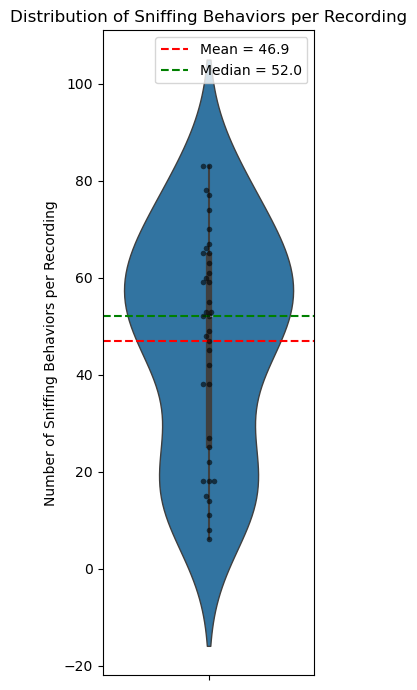

In [72]:
# Compute the number of sniffing behaviors per recording (per file)
sniff_counts_per_file = sniffing_behaviors.groupby("source_file").size().reset_index(name='Sniff_Count')

plt.figure(figsize=(3, 7))
sns.violinplot(y='Sniff_Count', data=sniff_counts_per_file, inner="box", linewidth=1)
sns.swarmplot(y='Sniff_Count', data=sniff_counts_per_file, color="k", alpha=0.6, size=4)
plt.axhline(sniff_counts_per_file['Sniff_Count'].mean(), color='r', linestyle='dashed', linewidth=1.5, label=f"Mean = {sniff_counts_per_file['Sniff_Count'].mean():.1f}")
plt.axhline(sniff_counts_per_file['Sniff_Count'].median(), color='g', linestyle='dashed', linewidth=1.5, label=f"Median = {sniff_counts_per_file['Sniff_Count'].median():.1f}")

plt.ylabel("Number of Sniffing Behaviors per Recording")
plt.title("Distribution of Sniffing Behaviors per Recording")
plt.legend()
plt.tight_layout()
plt.show()

Percentage of Sniffing Behaviors Across Recordings

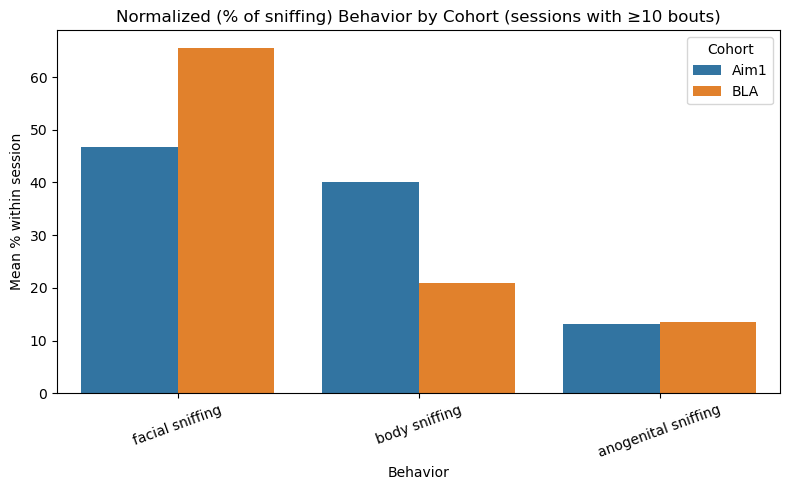

Sessions per cohort (≥10 bouts): {'Aim1': 7, 'BLA': 29}
Excluded sessions (sniffing <10): ['BLAcm_1_3_1_1_20260106_122823_boris_AJ_with_image_indices', 'BLAcm_3_2_3_3_20260107_140924_boris_AJ_with_image_indices']


In [73]:
# Calculate per-file sniffing counts
sniff_counts_per_file = sniffing_behaviors.groupby("source_file").size()

# Identify files with too few sniffing behaviors (<10)
low_sniff_files = sniff_counts_per_file[sniff_counts_per_file < 10].index.tolist()

# Optionally track for later exclusion
boris_files_to_exclude = list(low_sniff_files)  # to be used later as needed

# Remove these from the DataFrame
sniffing_behaviors_plot = sniffing_behaviors[~sniffing_behaviors["source_file"].isin(low_sniff_files)].copy()

# Calculate normalized behavior frequencies for each file
file_behavior_counts = (
    sniffing_behaviors_plot.groupby(["source_file", "Behavior"]).size().unstack(fill_value=0)
)
file_behavior_perc = file_behavior_counts.div(file_behavior_counts.sum(axis=1), axis=0) * 100

# Map files to cohorts to allow grouping by cohort in subsequent average
file_to_cohort = sniffing_behaviors_plot.set_index("source_file")["cohort"].to_dict()
file_behavior_perc["cohort"] = file_behavior_perc.index.map(lambda x: file_to_cohort.get(x, "Unknown"))

# Average percentages per behavior per cohort for plotting
behavior_perc_long = file_behavior_perc.reset_index().melt(
    id_vars=["source_file", "cohort"], var_name="Behavior", value_name="Percentage"
)
mean_perc = (
    behavior_perc_long.groupby(["Behavior", "cohort"])["Percentage"]
    .mean()
    .reset_index()
)

# Plot barplot of mean percentages of behaviors by cohort
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=mean_perc,
    x="Behavior",
    y="Percentage",
    hue="cohort",
    order=sniffing_behaviors_plot["Behavior"].value_counts().index
)
plt.title("Normalized (% of sniffing) Behavior by Cohort (sessions with ≥10 bouts)")
plt.xlabel("Behavior")
plt.ylabel("Mean % within session")
plt.legend(title='Cohort')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("Sessions per cohort (≥10 bouts):", sniffing_behaviors_plot.groupby("cohort")["source_file"].nunique().to_dict())
print("Excluded sessions (sniffing <10):", boris_files_to_exclude)

Average Sniffing Count/Duration Across Recordings

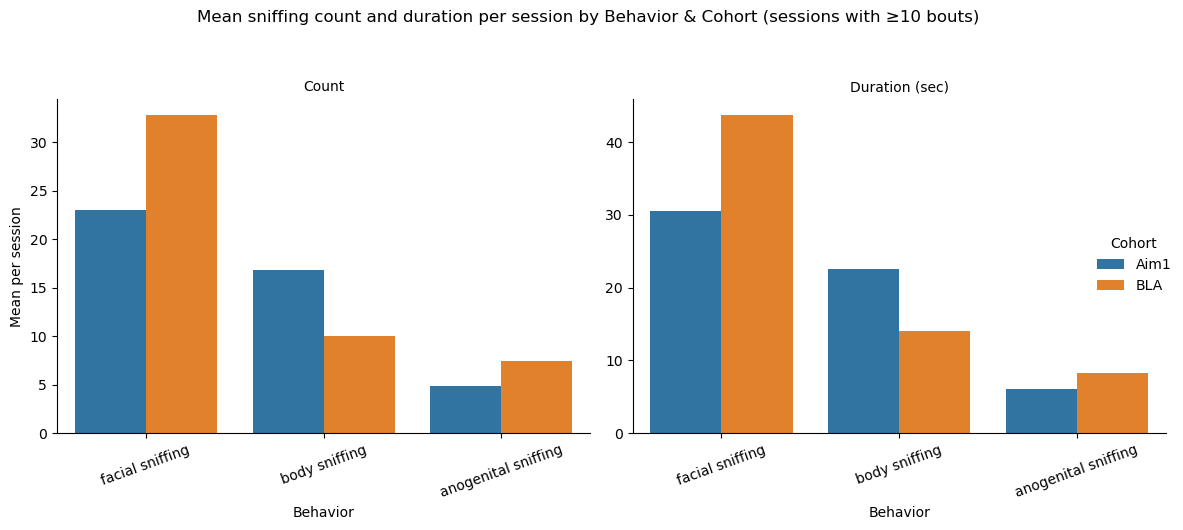

In [74]:
# Bar plot: mean sniffing count and duration per behavior per cohort (sessions with ≥10 bouts)

# Per-file totals: bout count and total duration per sniffing behavior
sniffing_counts = (
    sniffing_behaviors_plot.groupby(["source_file", "Behavior"]).size().unstack(fill_value=0)
)
sniffing_duration = (
    sniffing_behaviors_plot.groupby(["source_file", "Behavior"])["Duration"].sum().unstack(fill_value=0)
)

for df in (sniffing_counts, sniffing_duration):
    df["cohort"] = df.index.map(lambda x: file_to_cohort.get(x, "Unknown"))

sniffing_counts_long = sniffing_counts.reset_index().melt(
    id_vars=["source_file", "cohort"], var_name="Behavior", value_name="Sniff_Count"
)
sniffing_duration_long = sniffing_duration.reset_index().melt(
    id_vars=["source_file", "cohort"], var_name="Behavior", value_name="Sniff_Duration"
)

mean_sniff_count = (
    sniffing_counts_long.groupby(["Behavior", "cohort"])["Sniff_Count"]
    .mean()
    .reset_index()
)
mean_sniff_dur = (
    sniffing_duration_long.groupby(["Behavior", "cohort"])["Sniff_Duration"]
    .mean()
    .reset_index()
)

# Order behaviors by total sniffing time summed across cohorts (descending)
behavior_order_by_time = (
    mean_sniff_dur.groupby("Behavior")["Sniff_Duration"]
    .sum()
    .sort_values(ascending=False)
    .index.tolist()
)

plot_data = pd.concat(
    [
        mean_sniff_count.assign(Metric="Count", Value=lambda d: d["Sniff_Count"]),
        mean_sniff_dur.assign(Metric="Duration (sec)", Value=lambda d: d["Sniff_Duration"]),
    ],
    ignore_index=True,
)[["Behavior", "cohort", "Metric", "Value"]]

g = sns.catplot(
    data=plot_data,
    x="Behavior",
    y="Value",
    hue="cohort",
    col="Metric",
    kind="bar",
    order=behavior_order_by_time,
    height=5,
    aspect=1.1,
    sharey=False,
)
g.set_axis_labels("Behavior", "Mean per session")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)
g.fig.suptitle(
    "Mean sniffing count and duration per session by Behavior & Cohort (sessions with ≥10 bouts)",
    y=1.05,
)
g.legend.set_title("Cohort")
plt.tight_layout()
plt.show()

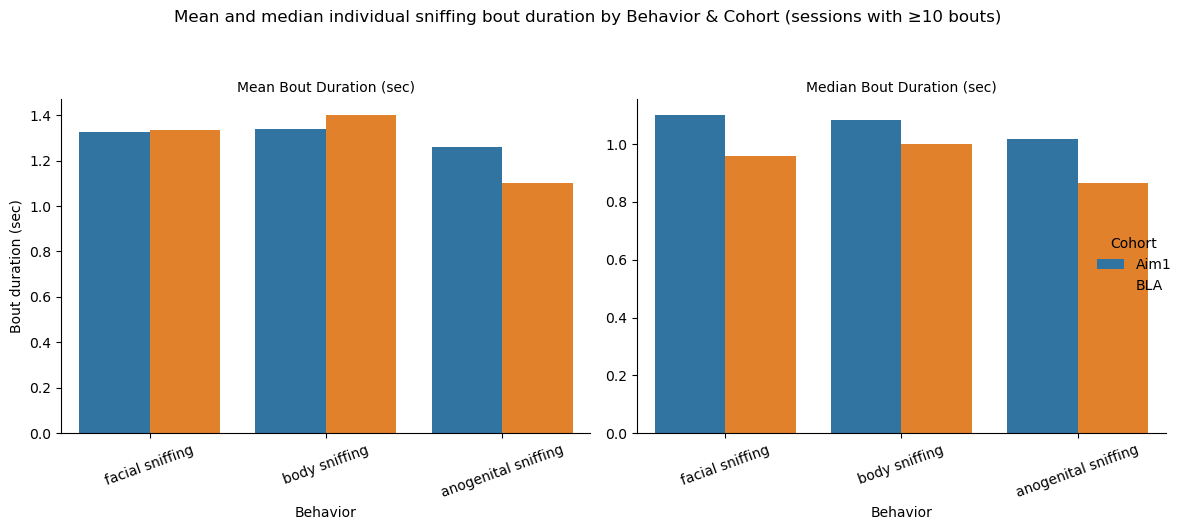

In [75]:
# Compute mean and median individual bout duration (not session sum, but per bout averaged within each behavior/cohort group)
bout_duration_stats = (
    sniffing_behaviors_plot.groupby(["Behavior", "cohort"])["Duration"]
    .agg(Mean_Bout_Duration="mean", Median_Bout_Duration="median")
    .reset_index()
)

# Keep the same behavior order as original
behavior_order = behavior_order_by_time

# Prepare plotting DataFrame for both mean and median
plot_bout_dur = pd.concat(
    [
        bout_duration_stats.assign(
            Metric="Mean Bout Duration (sec)", 
            Value=lambda d: d["Mean_Bout_Duration"]
        ),
        bout_duration_stats.assign(
            Metric="Median Bout Duration (sec)", 
            Value=lambda d: d["Median_Bout_Duration"]
        ),
    ],
    ignore_index=True,
)[["Behavior", "cohort", "Metric", "Value"]]

# Make bar plot in faceted style (mean and median side by side)
g2 = sns.catplot(
    data=plot_bout_dur,
    x="Behavior",
    y="Value",
    hue="cohort",
    col="Metric",
    kind="bar",
    order=behavior_order,
    height=5,
    aspect=1.1,
    sharey=False,
)

g2.set_axis_labels("Behavior", "Bout duration (sec)")
g2.set_titles("{col_name}")
for ax in g2.axes.flat:
    ax.tick_params(axis="x", rotation=20)
g2.fig.suptitle(
    "Mean and median individual sniffing bout duration by Behavior & Cohort (sessions with ≥10 bouts)",
    y=1.05,
)
g2.legend.set_title("Cohort")
plt.tight_layout()
plt.show()

Total Quantity of Sniffing Behaviors Across Recordings

C:\Users\thoma\AppData\Local\Temp\ipykernel_29976\799914446.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


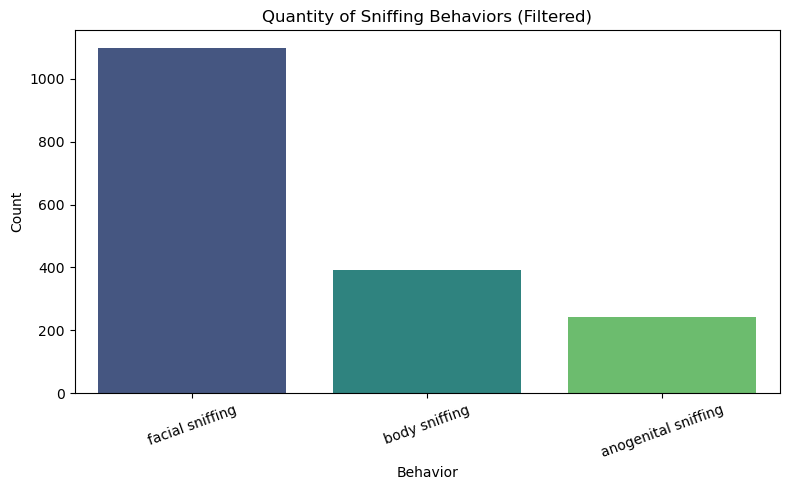

Total sniffing behaviors (filtered): 1734

Count per behavior:
  facial sniffing: 1099
  body sniffing: 393
  anogenital sniffing: 242

Total time sniffing for each behavior (seconds):
  anogenital sniffing: 272.58 sec
  body sniffing: 547.29 sec
  facial sniffing: 1469.30 sec


In [76]:
# Filter out Aim1 1.1 & 1.2 subjects and threshold <10 sniffing behaviors

# Identify source_files (Boris files) that correspond to subject 1.1 or 1.2 from Aim1
aim1_subjects_to_exclude = ["1_1", "1_2"]
# heuristic: find files from Aim1 cohort where subject is '1_1' or '1_2'
to_exclude_files = sniffing_behaviors_plot[
    (sniffing_behaviors_plot['cohort'] == "Aim1") 
    & (sniffing_behaviors_plot['source_file'].str.contains("_1_1_|_1_2_"))
]['source_file'].unique().tolist()

# Count number of sniffing bouts per source_file
sniff_bout_counts = sniffing_behaviors_plot.groupby('source_file').size()

# Filter out files with <10 sniff bouts
valid_files = sniff_bout_counts[sniff_bout_counts >= 10].index.tolist()

# Filter main DataFrame
sniffing_behaviors_filtered = sniffing_behaviors_plot[
    (~sniffing_behaviors_plot['source_file'].isin(to_exclude_files)) &
    (sniffing_behaviors_plot['source_file'].isin(valid_files))
]

# Bar plot of sniffing behavior quantity
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=sniffing_behaviors_filtered, 
    x="Behavior", 
    order=sniffing_behaviors_filtered["Behavior"].value_counts().index,
    palette="viridis"
)
plt.title("Quantity of Sniffing Behaviors (Filtered)")
plt.xlabel("Behavior")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Print total quantity
total_behaviors = len(sniffing_behaviors_filtered)
print(f"Total sniffing behaviors (filtered): {total_behaviors}")

# Count per behavior
count_per_behavior = sniffing_behaviors_filtered['Behavior'].value_counts()
print("\nCount per behavior:")
for behavior, count in count_per_behavior.items():
    print(f"  {behavior}: {count}")

# Total time sniffing for each behavior
total_time_per_behavior = sniffing_behaviors_filtered.groupby('Behavior')['Duration'].sum()
print("\nTotal time sniffing for each behavior (seconds):")
for behavior, total_time in total_time_per_behavior.items():
    print(f"  {behavior}: {total_time:.2f} sec")

In [77]:
sniffing_behaviors.head()

,Behavior,Initiator,Start,Stop,Duration,source_file,cohort,h5_path,boris_path,subject,social_agent
2,facial sniffing,social_agent,17.867,18.700,0.833,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,1-1,1-2
3,facial sniffing,subject,18.200,18.700,0.500,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,1-1,1-2
16,facial sniffing,social_agent,113.767,114.867,1.100,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,1-1,1-2
28,facial sniffing,subject,196.467,196.967,0.500,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,1-1,1-2
29,body sniffing,subject,218.467,220.233,1.766,AIM1cm_1_1_1_2_20250623_111352,Aim1,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,1-1,1-2


---

## Respiration Feature Extraction, Behavior Alignment, & Rank Assignment

### Aim1 Rank Map

In [78]:
aim1_rank_map = {
    "1_1": "Subordinate",
    "1_2": "Dominant",
    "2_3": "Subordinate",
    "2_4": "Dominant",
    "3_5": "Subordinate",
    "3_6": "Dominant",
    "4_7": "Subordinate",
    "4_8": "Dominant"
}

### Feature Extraction using Breathmetrics - Functions

In [79]:
# Main build loop (interaction bouts only):
#   - AIM1cm / BLAcm : raw 20 kHz -> 400 Hz via load_rank_resp_signal_interactions
#   - All bouts padded/cropped to target_dur, anchored at interaction onset

# length window of bout taken
def _feature_window_bounds(bout_start, bout_stop, feature_window_mode="full", window_sec=2.0):
    """Return (start, stop) for feature extraction inside a BORIS bout."""
    if feature_window_mode == "full":
        return bout_start, bout_stop
    if feature_window_mode == "onset_2s":
        return bout_start, bout_start + window_sec
    if feature_window_mode == "first_2s":
        return bout_start, bout_start + window_sec
    if feature_window_mode == "last_2s":
        return bout_stop - window_sec, bout_stop
    raise ValueError(f"Unknown feature_window_mode: {feature_window_mode}")

# added features outside of brethmetric
def add_engineered_features(df):
    """Ratio features + per-subject / per-trial z-scores for all numeric resp columns."""
    df = df.copy()
    if {"mean_inhale_vol", "mean_exhale_vol"}.issubset(df.columns):
        df["vol_asymmetry"] = df["mean_inhale_vol"] / (df["mean_exhale_vol"].abs() + 1e-8)
    if {"mean_peak_insp_flow", "mean_peak_exp_flow"}.issubset(df.columns):
        df["peak_flow_ratio"] = df["mean_peak_insp_flow"] / (df["mean_peak_exp_flow"].abs() + 1e-8)

    meta = {
        "Behavior", "Initiator", "Start", "Stop", "Duration", "PreBoutRespRate", "Trial", "Subject",
        "social_agent", "Cohort", "Rank", "Type", "h5_path", "h5_filename", "boris_path", "boris_filename", "FeatureWindow",
    }
    numeric_cols = [
        c for c in df.columns
        if c not in meta and pd.api.types.is_numeric_dtype(df[c])
        and not c.endswith("_z_subject") and not c.endswith("_z_trial")
    ]
    for col in numeric_cols:
        df[f"{col}_z_subject"] = df.groupby("Subject")[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan
        )
        df[f"{col}_z_trial"] = df.groupby("Trial")[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan
        )
    return df


# loads and cleans each resp signal in the h5 folders 
# runs breathmetrics on signal
# Collects boris behaviors
# standardizes behaviors
# collect behavior window start stop times to create feature windows
# extracts window level features for each feature window
# creates dataframe of behaviors and their BM features along with metadata and engineered features 
def build_feature_matrix(
    resp_paths_interactions, boris_paths_valence,
    aim1_rank_map,
    target_dur=3.0, min_dur=1.0,
    pre_bout_window=2.0,
    bout_anchor="onset",
    feature_window_mode="full",
    feature_window_sec=2.0,
    data_type="rodentAirflow",
    target_srate=100,
    min_breaths_per_bout=2,
    subject_only=False,
    plot_dropped_bouts=True,
    max_dropped_plots_per_trial=3,
    dropped_plot_pad_sec=0.5,
    plot_session_overview=True,
):
    all_rows = []

    for trial, h5_path in resp_paths_interactions.items():
        print(f"\n[Interaction] {trial}")

        signal, time, fs, meta = load_rank_resp_signal_interactions(
            h5_path, target_rate=target_srate, prefer_raw=True, verbose=False
        )
        if signal is None:
            print(" Load failed"); continue
        if meta and meta.get("from_raw"):
            print(f"  source: {meta.get('source_key')} @ {meta.get('original_fs')} Hz -> {fs} Hz")

        # Signal Checks
        print("signal len:", len(signal))
        print("fs:", fs)
        print("nan count:", np.isnan(signal).sum())
        print("inf count:", np.isinf(signal).sum())
        print("min/max:", np.nanmin(signal), np.nanmax(signal))
        print("std:", np.nanstd(signal))
        print("first 10:", signal[:10])

        bm = fit_bm_session(signal, fs, data_type=data_type)
        if bm is None: continue
        print(f"  ✓ {len(bm.inhaleOnsets)} breaths detected")

        trial_parts = trial.split("_")
        subj          = "_".join(trial_parts[1:3])
        social_agent  = "_".join(trial_parts[3:5]) if len(trial_parts) >= 5 else np.nan
        cohort        = "Aim1" if trial.startswith("AIM1") else ("BLA" if trial.startswith("BLA") else "Other")
        rank          = aim1_rank_map.get(subj, np.nan)

        if trial not in boris_paths_valence:
            print(f"   No BORIS for {trial}, skipping"); continue

        boris_path = boris_paths_valence[trial]
        h5_filename = Path(h5_path).name
        boris_filename = Path(boris_path).name
        boris_df = load_clean_boris(boris_path, subject_only=subject_only)
        if boris_df.empty:
            print(f"   Empty BORIS, skipping"); continue

        boris_df = standardize_bouts_to_target(boris_df, time[0], time[-1],
                                        target_dur=target_dur, min_dur=min_dur,
                                        anchor=bout_anchor)
        n_dropped_breaths = 0
        n_dropped_plots = 0
        kept_bouts, dropped_bouts = [], []
        for _, bout in boris_df.iterrows():
            feat_start, feat_stop = _feature_window_bounds(
                bout["Start"], bout["Stop"],
                feature_window_mode=feature_window_mode,
                window_sec=feature_window_sec,
            )
            feats = extract_bout_features(
                bm, feat_start, feat_stop,
                min_breaths=min_breaths_per_bout,
            )
            if feats is None or feats["n_breaths"] < min_breaths_per_bout:
                n_dropped_breaths += 1
                dropped_bouts.append({
                    "Start": bout["Start"],
                    "Stop": bout["Stop"],
                    "Behavior": bout.get("Behavior", np.nan),
                })
                if plot_dropped_bouts and n_dropped_plots < max_dropped_plots_per_trial:
                    plot_dropped_bout_diagnostic(
                        signal, time, fs, bm,
                        bout["Start"], bout["Stop"],
                        feat_start, feat_stop,
                        min_breaths_required=min_breaths_per_bout,
                        behavior=bout.get("Behavior", np.nan),
                        trial=trial,
                        pad_sec=dropped_plot_pad_sec,
                    )
                    n_dropped_plots += 1
                continue

            pre_start = max(time[0], bout["Start"] - pre_bout_window)
            pre_feats = extract_bout_features(
                bm, pre_start, bout["Start"],
                min_breaths=1,
            )
            pre_rate  = pre_feats["breathing_rate_hz"] if pre_feats else np.nan

            row = {
                "Behavior"        : bout.get("Behavior", np.nan),
                "Initiator"       : bout.get("Initiator", np.nan),
                "Start"           : bout["Start"],
                "Stop"            : bout["Stop"],
                "Duration"        : bout["Duration"],
                "PreBoutRespRate"  : pre_rate,
                "Trial"           : trial,
                "Subject"         : subj,
                "social_agent"    : social_agent,
                "Cohort"          : cohort,
                "Rank"            : rank,
                "Type"            : "Interaction",
                "h5_path"         : h5_path,
                "h5_filename"     : h5_filename,
                "boris_path"      : boris_path,
                "boris_filename"  : boris_filename,
                "FeatureWindow"   : feature_window_mode,
            }
            row.update(feats)
            row["resp_rate_delta"] = (
                row["breathing_rate_hz"] - pre_rate
                if not np.isnan(pre_rate) else np.nan
            )
            kept_bouts.append({
                "Start": bout["Start"],
                "Stop": bout["Stop"],
                "Behavior": bout.get("Behavior", np.nan),
            })
            all_rows.append(row)

        if n_dropped_breaths:
            msg = f"  → Dropped {n_dropped_breaths} bouts (<{min_breaths_per_bout} breaths in feature window)"
            if plot_dropped_bouts and n_dropped_plots:
                msg += f"; plotted {n_dropped_plots}"
            print(msg)

        if plot_session_overview:
            plot_recording_bout_overview(
                signal, time, trial,
                kept_bouts, dropped_bouts,
            )

    # ── Assemble ───────────────────────────────────────────────
    if not all_rows:
        print("\n No rows collected."); return pd.DataFrame()

    master_df = pd.DataFrame(all_rows).reset_index(drop=True)

    master_df["breathing_rate_z"] = (
        master_df.groupby("Trial")["breathing_rate_hz"]
        .transform(lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan)
    )

    print(f"\nFeature matrix: {len(master_df)} rows × {len(master_df.columns)} cols")
    print(f"   Trials    : {master_df['Trial'].nunique()}")
    print(f"   Subjects  : {master_df['Subject'].nunique()}")
    print(f"   Type dist :\n{master_df['Type'].value_counts()}")
    if "Initiator" in master_df.columns:
        print(f"   Initiator dist :\n{master_df['Initiator'].value_counts()}")

    return master_df

### Aim1

### BLA subject / social-agent BORIS pairs (VT_SA + VT_CM)

Most BLA sessions have one BORIS export. A few sessions were scored separately for the **subject** (`VT_SA`) and **social agent** (`VT_CM`). The dict below groups those pairs so each can be aligned to the same respiration H5.

In [80]:
# Outlier sessions with separate subject vs social-agent BORIS exports
bla_boris_sa_cm_pairs = discover_bla_boris_sa_cm_pairs(bla_cm_boris_dir, bla_cm_h5_dir)

pair_rows = []
for session_id, pair in bla_boris_sa_cm_pairs.items():
    pair_rows.append({
        "session_id": session_id,
        "subject_boris": Path(pair["subject_boris"]).name,
        "social_agent_boris": Path(pair["social_agent_boris"]).name,
        "h5": Path(pair["h5"]).name if pair.get("h5") else None,
    })

bla_boris_sa_cm_pairs_df = pd.DataFrame(pair_rows)
print(f"Paired VT_SA / VT_CM sessions: {len(bla_boris_sa_cm_pairs)}")
display(bla_boris_sa_cm_pairs_df)

# Full paths remain in bla_boris_sa_cm_pairs[session_id]
bla_boris_sa_cm_pairs

Paired VT_SA / VT_CM sessions: 8


,session_id,subject_boris,social_agent_boris,h5
0,1_1_1_3_20260107_163611,1_1_i_cm_1_3_s_20260107_163611.1_VT_SA.csv,1_1_2_i_cm_1_3_s_20260107_163611.1_VT_CM.csv,1_1_i_cm_1_3_s_20260107_163611.h5
1,1_2_1_3_20260108_114416,1_2_d_cm_1_3_s_20260108_114416.1_VT_SA.csv,1_2_2_d_cm_1_3_s_20260108_114416.1_VT_CM.csv,1_2_d_cm_1_3_s_20260108_114416.h5
2,2_1_2_2_20260108_112426,2_1_d_cm_2_2_s_20260108_112426.1_VT_SA.csv,2_1_2_d_cm_2_2_s_20260108_112426.1_VT_CM.csv,2_1_d_cm_2_2_s_20260108_112426.h5
3,2_2_2_1_20260108_120453,2_2_s_cm_2_1_d_20260108_120453.1_VT_SA.csv,2_2_2_s_cm_2_1_d_20260108_120453.1_VT_CM.csv,2_2_s_cm_2_1_d_20260108_120453.h5
4,3_3_3_2_20260107_171330,3_3_s_cm_3_2_d_20260107_171330.1_VT_SA.csv,3_3_2_s_cm_3_2_d_20260107_171330.1_VT_CM.csv,3_3_s_cm_3_2_d_20260107_171330.h5
5,4_1_4_2_20260107_160439,4_1_s_cm_4_2_d_20260107_160439.1_VT_SA.csv,4_1_2_s_cm_4_2_d_20260107_160439.1_VT_CM.csv,4_1_s_cm_4_2_d_20260107_160439.h5
6,4_2_4_1_20260107_150836,4_2_d_cm_4_1_s_20260107_150836.1_VT_SA.csv,4_2_2_d_cm_4_1_s_20260107_150836.1_VT_CM.csv,4_2_d_cm_4_1_s_20260107_150836.h5
7,8_1_8_2_20260107_152812,8_1_s_cm_8_2_d_20260107_152812.1_VT_SA.csv,8_1_2_d_cm_8_2_s_20260107_152812.1_VT_CM.csv,8_1_s_cm_8_2_d_20260107_152812.h5


{'1_1_1_3_20260107_163611': {'session_key': ('1_1',
   '1_3',
   '20260107',
   '163611'),
  'subject_boris': 'C:\\Users\\thoma\\UF Dropbox\\Thomas Heeps\\Padilla-Coreano Lab\\2025\\BLA_ChR_resp_pilot1 (SS)\\BLA_resp_ChR_cm_boris\\1_1_i_cm_1_3_s_20260107_163611.1_VT_SA.csv',
  'social_agent_boris': 'C:\\Users\\thoma\\UF Dropbox\\Thomas Heeps\\Padilla-Coreano Lab\\2025\\BLA_ChR_resp_pilot1 (SS)\\BLA_resp_ChR_cm_boris\\1_1_2_i_cm_1_3_s_20260107_163611.1_VT_CM.csv',
  'h5': 'C:\\Users\\thoma\\UF Dropbox\\Thomas Heeps\\Padilla-Coreano Lab\\2025\\BLA_ChR_resp_pilot1 (SS)\\BLA_resp_ChR_cm_hc\\h5_outputs\\1_1_i_cm_1_3_s_20260107_163611.h5'},
 '1_2_1_3_20260108_114416': {'session_key': ('1_2',
   '1_3',
   '20260108',
   '114416'),
  'subject_boris': 'C:\\Users\\thoma\\UF Dropbox\\Thomas Heeps\\Padilla-Coreano Lab\\2025\\BLA_ChR_resp_pilot1 (SS)\\BLA_resp_ChR_cm_boris\\1_2_d_cm_1_3_s_20260108_114416.1_VT_SA.csv',
  'social_agent_boris': 'C:\\Users\\thoma\\UF Dropbox\\Thomas Heeps\\Padilla-Core

In [81]:
# --- Session-aligned Aim1 + BLA interaction paths ---
resp_paths_interactions, boris_paths_interactions, bla_aim1_rank_map, bla_boris_sa_cm_pairs = build_interaction_boris_catalog(
    aim1_h5_dir,
    aim1_boris_dir,
    bla_cm_h5_dir,
    bla_cm_boris_dir,
    aim1_skip_boris_stems={"CM_s3_6_sub3_5_20250623_174348"},
    aim1_exclude_boris_names={"CM_s4_8_sub4_7_20250623.csv"},
)

resp_paths_cm_aim1 = {k: v for k, v in resp_paths_interactions.items() if k.startswith("AIM1")}
boris_paths_cm_aim1 = {k: v for k, v in boris_paths_interactions.items() if k.startswith("AIM1")}
print(f"Aim1 cm trials indexed: {len(resp_paths_cm_aim1)} (resp) / {len(boris_paths_cm_aim1)} (boris)")
print(f"BLA VT_SA/VT_CM paired sessions: {len(bla_boris_sa_cm_pairs)}")

  → Excluding Aim1 BORIS: CM_s4_8_sub4_7_20250623.csv
  → Aim1 multiple BORIS exports for one session; using CM_s1_2_sub1_1_20250623_133932.1.csv; also found: ['CM_s1_2_sub1_1_20250623_133932.1_VT.csv']
  ⚠️ No matching BORIS for CM_s3_5_d3_6_20250623_170708_merged.h5 (stem=CM_s3_5_d3_6_20250623_170708)
  ⚠️ Skipping empty BORIS stem: CM_s3_6_sub3_5_20250623_174348
  ⚠️ No matching BLA .h5 for BORIS 1_3_2_s_1_2_d_20260107_165340.1_boris_AJ_with_image_indices_with_image_indices.csv (key=('1_3', '1_2', '20260107', '165340'))
Aim1 cm trials indexed: 7 (resp) / 7 (boris)
BLA VT_SA/VT_CM paired sessions: 8


### CM-BLA

In [82]:
# --- BLA cagemate paths (indexed in build_interaction_boris_catalog) ---
resp_paths_cm_bla = {k: v for k, v in resp_paths_interactions.items() if k.startswith("BLA")}
boris_paths_cm_bla = {k: v for k, v in boris_paths_interactions.items() if k.startswith("BLA")}
print(f"BLA cm trials indexed: {len(resp_paths_cm_bla)} (resp) / {len(boris_paths_cm_bla)} (boris)")

BLA cm trials indexed: 31 (resp) / 31 (boris)


### Aligning Respiration & Behavior


BLA cm trials added: 31 (resp) / 31 (boris)
Total interaction trials (AIM1+BLA): 38
Upstream exclusion: 38 -> 23 trials (15 skipped)
  skip AIM1cm_1_2_1_1_20250623_133932 (low_sniffs)
  skip BLAcm_2_1_2_2_20260108_112426_VT_CM (subject=2_1@BLA)
  skip BLAcm_2_1_2_3_20260106_105109_BORIS_SS (subject=2_1@BLA)
  skip BLAcm_2_1_2_2_20260108_112426_VT_SA (subject=2_1@BLA)
  skip BLAcm_2_2_2_1_20260108_120453_VT_CM (subject=2_2@BLA)
  skip BLAcm_2_2_2_3_20260106_132549_boris_AJ_with_image_indices (subject=2_2@BLA, low_sniffs)
  skip BLAcm_2_2_2_1_20260108_120453_VT_SA (subject=2_2@BLA)
  skip BLAcm_3_2_3_3_20260107_140924_boris_AJ_with_image_indices (low_sniffs)
  skip BLAcm_3_3_3_1_20260106_124546_boris_AJ_with_image_indices (subject=3_3@BLA, low_sniffs)
  skip BLAcm_3_3_3_2_20260107_171330_VT_CM (subject=3_3@BLA)
  skip BLAcm_3_3_3_2_20260107_171330_VT_SA (subject=3_3@BLA)
  skip BLAcm_4_3_4_1_20260107_113120_boris_AJ_with_image_indices (low_sniffs)
  skip BLAcm_5_1_5_2_20260106_120946_BO

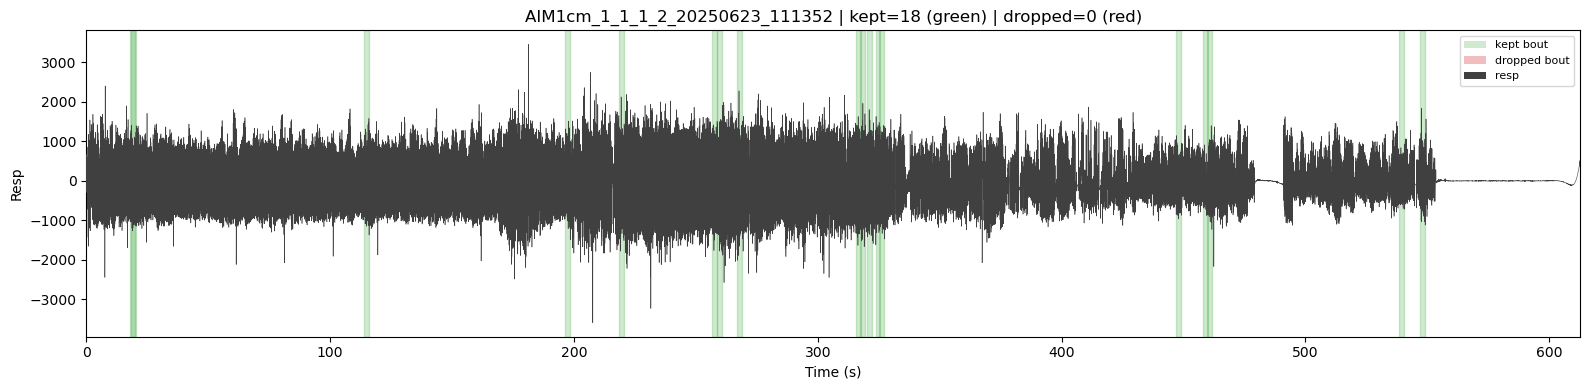


[Interaction] AIM1cm_2_3_2_4_20250623_151153
  source: resp @ 20000.0 Hz -> 400.0 Hz
signal len: 244574
fs: 400.0
nan count: 0
inf count: 0
min/max: -2824.2044650462353 8484.161843409045
std: 828.7419599937958
first 10: [-132.43629231   73.92022626  264.47483094  426.86300884  553.69759587
  641.68182539  690.52657101  702.0743548   679.60041348  627.2806112 ]
  ✓ 4027 breaths detected


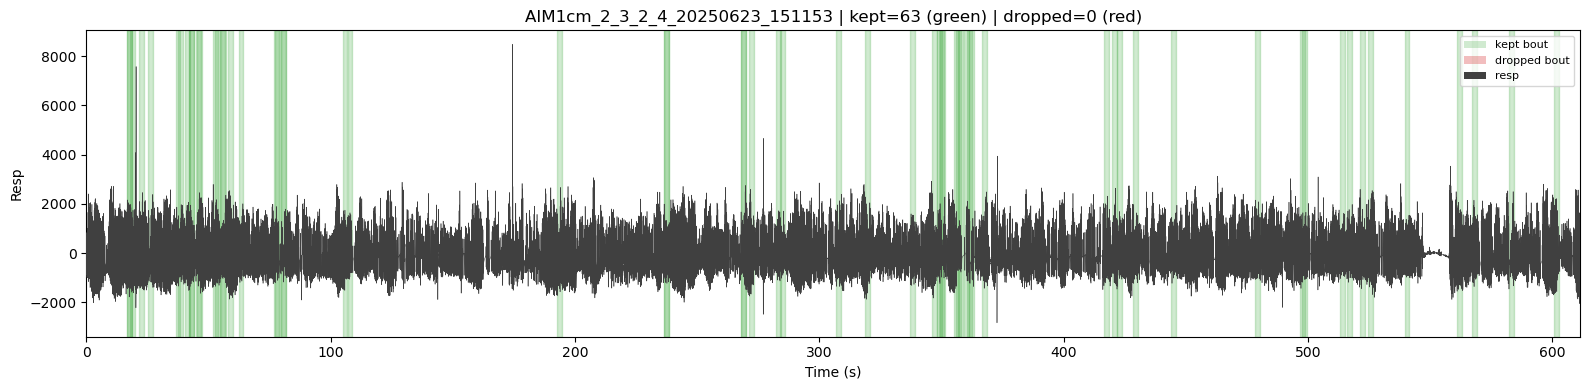


[Interaction] AIM1cm_2_4_2_3_20250623_143348
  source: resp @ 20000.0 Hz -> 400.0 Hz
signal len: 248786
fs: 400.0
nan count: 0
inf count: 0
min/max: -2992.975752513373 4910.112292344584
std: 759.130026332373
first 10: [ 91.56648416 216.00790712 331.52287814 431.84845483 514.01515893
 577.57434647 623.72772535 654.64525579 672.94629003 681.33063999]
  ✓ 3711 breaths detected


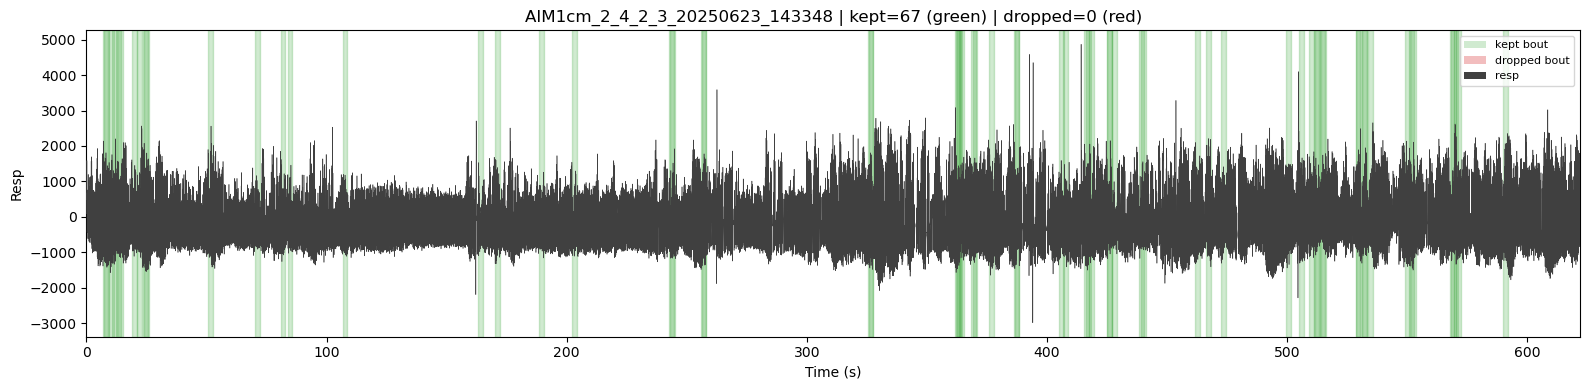


[Interaction] AIM1cm_3_5_3_6_20250623_160001
  source: resp @ 20000.0 Hz -> 400.0 Hz
signal len: 142163
fs: 400.0
nan count: 0
inf count: 0
min/max: -4213.228142220433 6183.170206797267
std: 1024.8089572018953
first 10: [ -375.1310901   -523.86951595  -672.72054277  -818.46160644
  -956.12795458 -1079.88974111 -1183.82367151 -1262.4101349
 -1310.83087837 -1325.12278192]
  ✓ 2698 breaths detected


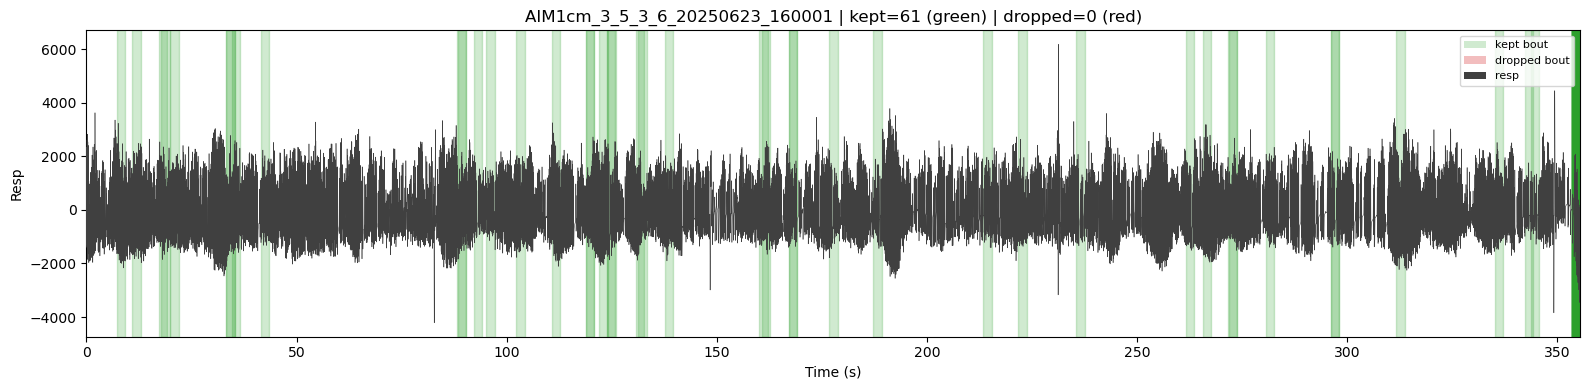


[Interaction] AIM1cm_4_7_4_8_20250623_193718
  source: resp @ 20000.0 Hz -> 400.0 Hz
signal len: 241276
fs: 400.0
nan count: 0
inf count: 0
min/max: -2792.599703324348 4644.868782551667
std: 908.5307546371789
first 10: [ -576.55127218  -546.36621298  -532.69960393  -546.31401873
  -591.24729455  -666.372784    -767.1925652   -887.26727994
 -1019.31551751 -1156.0036353 ]
  ✓ 4023 breaths detected


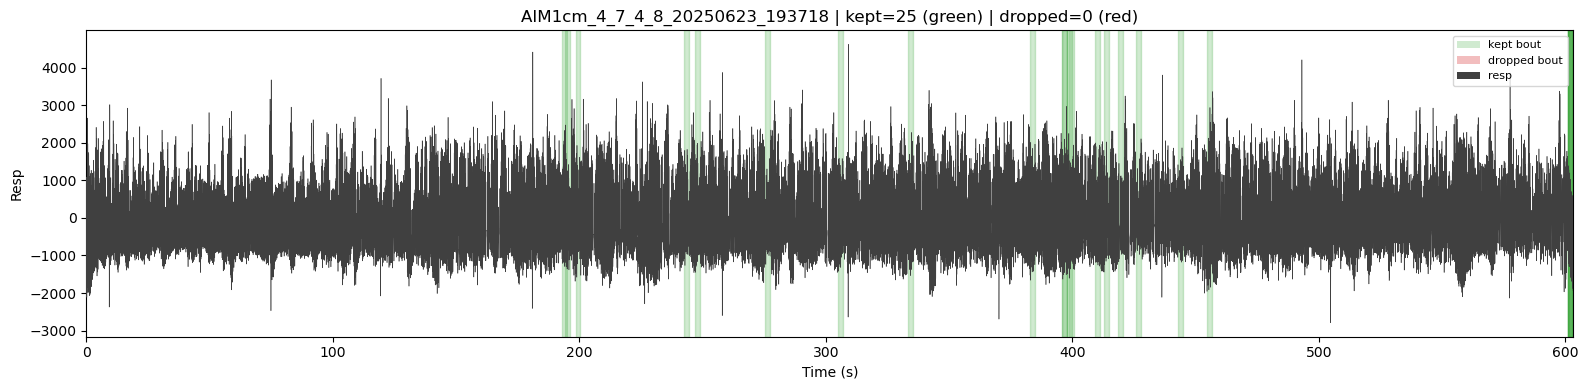


[Interaction] AIM1cm_4_8_4_7_20250623_182649
  source: resp @ 20000.0 Hz -> 400.0 Hz
signal len: 242034
fs: 400.0
nan count: 0
inf count: 0
min/max: -3513.958951763678 4920.5394412534915
std: 914.7975510336884
first 10: [-330.21152943 -298.855685   -269.55569603 -243.49656068 -221.22606816
 -202.76591564 -187.74045858 -175.47567369 -165.073554   -155.46395125]
  ✓ 3945 breaths detected


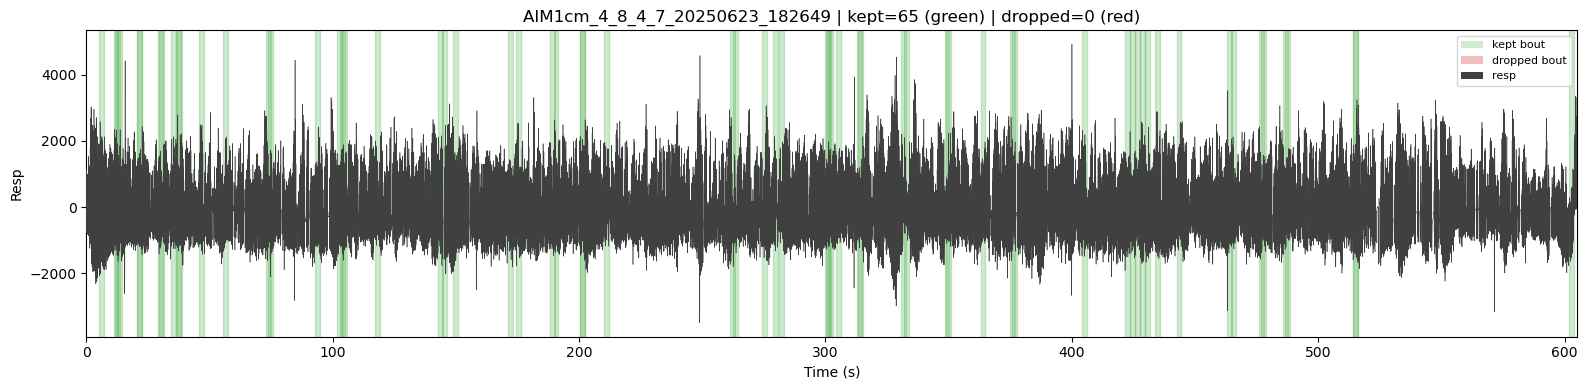


[Interaction] BLAcm_1_1_1_2_20260106_134350_BORIS_SS
  source: analog/1_1_d_cm_1_2_i_20260106_134350.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 244108
fs: 400.0
nan count: 0
inf count: 0
min/max: -1430.531720725979 2763.055654991224
std: 363.5253046188599
first 10: [130.64495705 117.47287926 108.32394157 106.64723588 114.95941221
 134.89609561 167.29881222 212.27861989 269.26751282 337.06468093]
  ✓ 4085 breaths detected


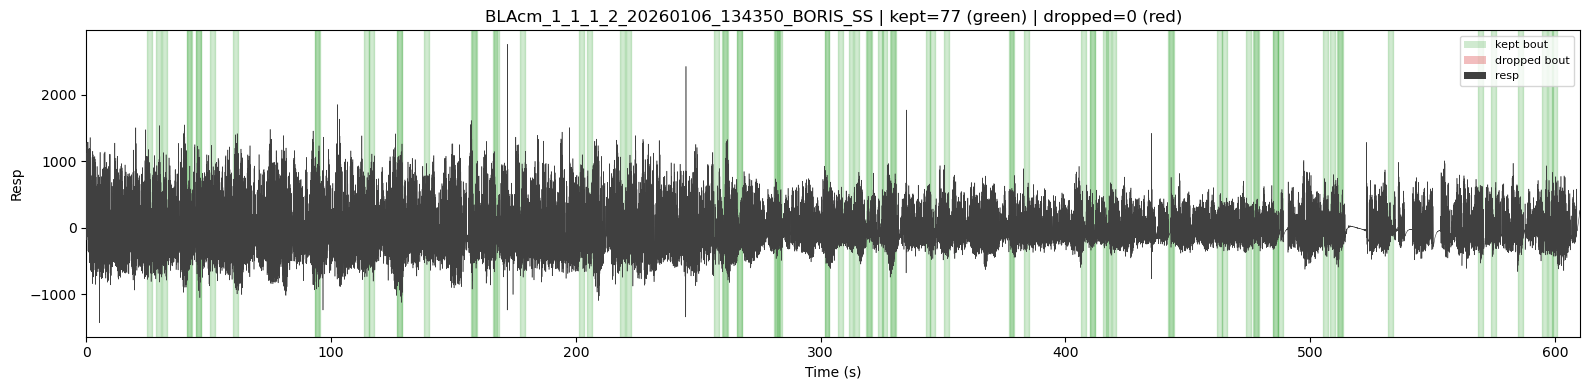


[Interaction] BLAcm_1_1_1_3_20260107_163611_VT_CM
  source: analog/1_1_i_cm_1_3_s_20260107_163611.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 245743
fs: 400.0
nan count: 0
inf count: 0
min/max: -1637.788051916509 2633.7965356801246
std: 435.0550104058819
first 10: [ 10.95064639 167.08891248 314.92075236 446.94986648 557.39033856
 642.15100477 698.73094092 726.11271504 724.64069237 695.8824369 ]
  ✓ 4820 breaths detected


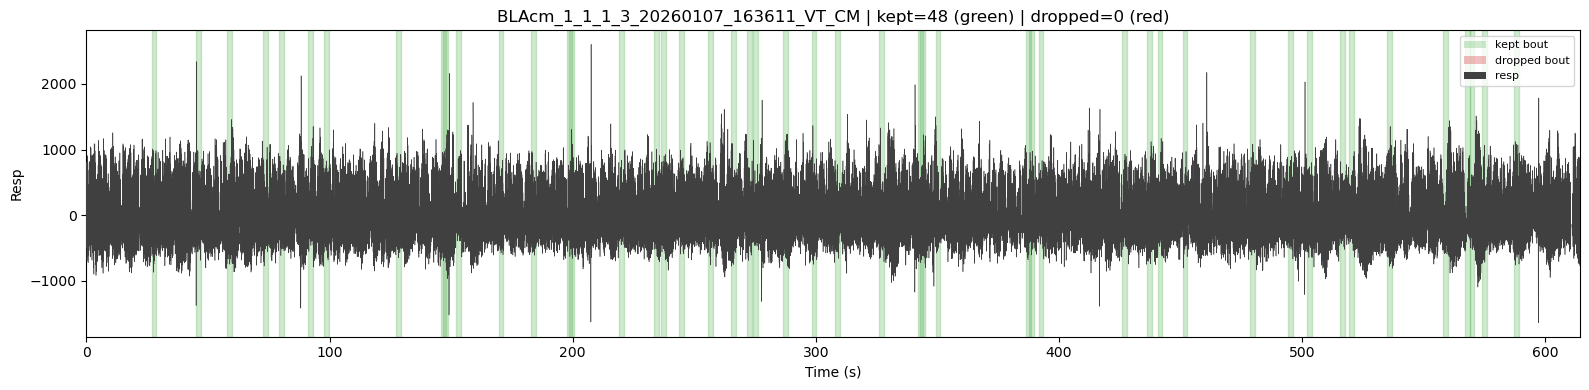


[Interaction] BLAcm_1_1_1_3_20260107_163611_VT_SA
  source: analog/1_1_i_cm_1_3_s_20260107_163611.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 245743
fs: 400.0
nan count: 0
inf count: 0
min/max: -1637.788051916509 2633.7965356801246
std: 435.0550104058819
first 10: [ 10.95064639 167.08891248 314.92075236 446.94986648 557.39033856
 642.15100477 698.73094092 726.11271504 724.64069237 695.8824369 ]
  ✓ 4820 breaths detected


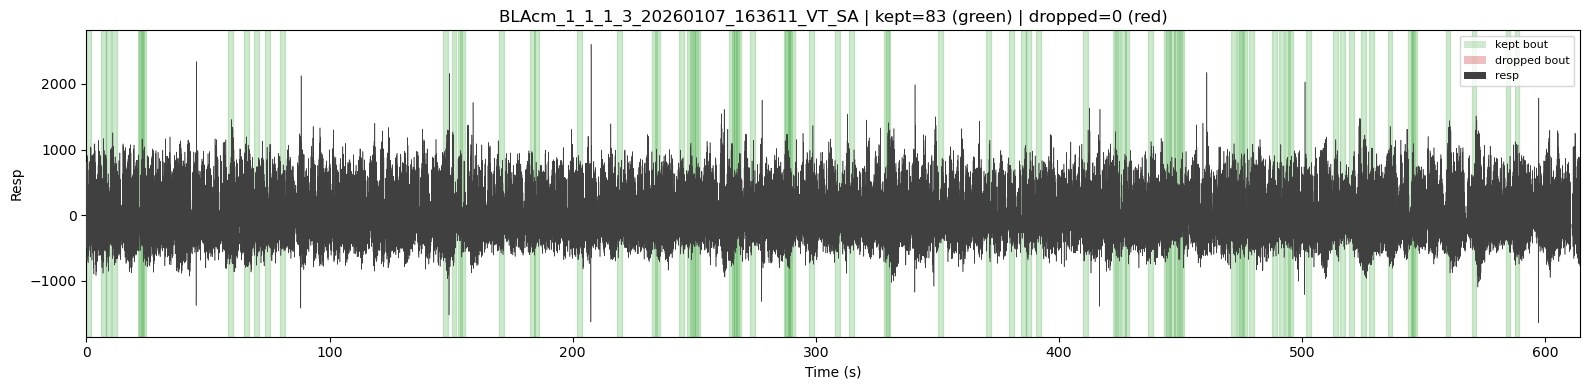


[Interaction] BLAcm_1_2_1_3_20260108_114416_VT_CM
  source: analog/1_2_d_cm_1_3_s_20260108_114416.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 241419
fs: 400.0
nan count: 0
inf count: 0
min/max: -811.9982392395466 3428.0151585749127
std: 205.15651444534967
first 10: [-76.04747817 -64.15302312 -53.24035128 -43.93170821 -36.4889293
 -30.9018832  -26.9859941  -24.45522734 -22.97222523 -22.17782983]
  ✓ 3980 breaths detected


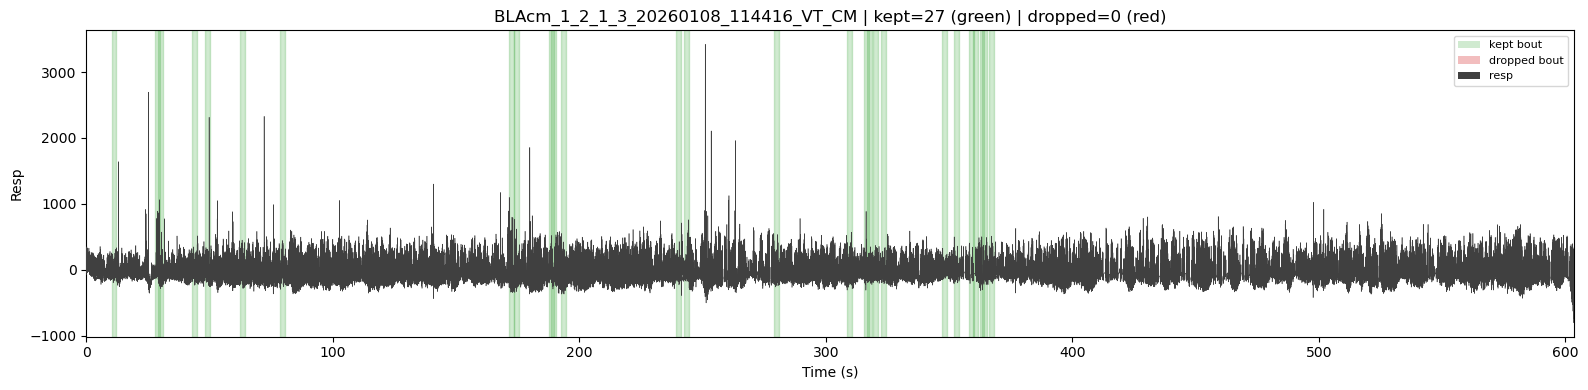


[Interaction] BLAcm_1_2_1_3_20260108_114416_VT_SA
  source: analog/1_2_d_cm_1_3_s_20260108_114416.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 241419
fs: 400.0
nan count: 0
inf count: 0
min/max: -811.9982392395466 3428.0151585749127
std: 205.15651444534967
first 10: [-76.04747817 -64.15302312 -53.24035128 -43.93170821 -36.4889293
 -30.9018832  -26.9859941  -24.45522734 -22.97222523 -22.17782983]
  ✓ 3980 breaths detected


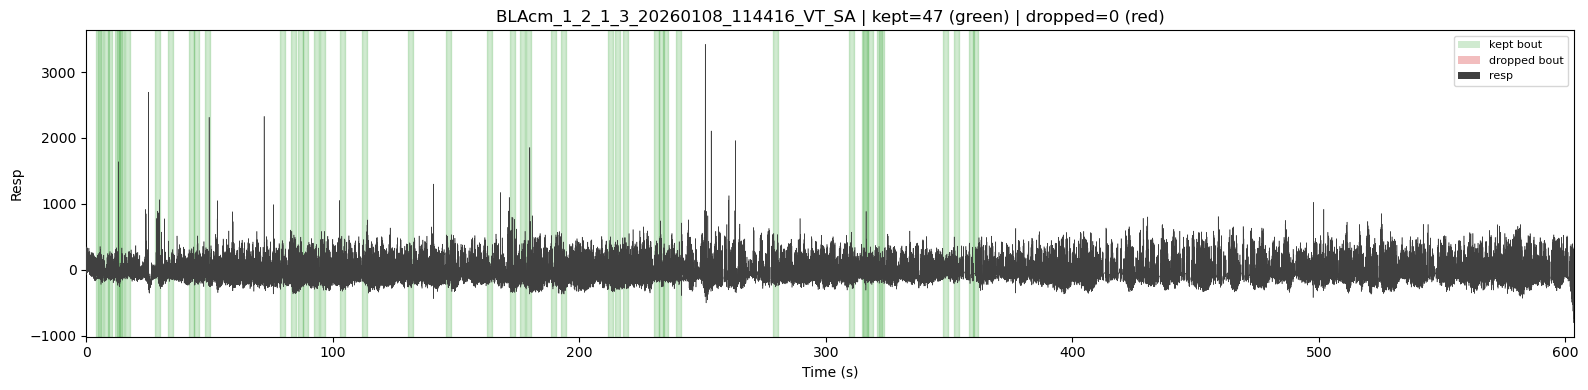


[Interaction] BLAcm_1_3_1_1_20260106_122823_boris_AJ_with_image_indices
  source: analog/1_3_s_cm_1_1_i_20260106_122823.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 241862
fs: 400.0
nan count: 0
inf count: 0
min/max: -1300.01852612208 5841.667598847776
std: 367.9590461371803
first 10: [ 398.77859721  495.60966019  593.25405144  691.68776433  790.28587947
  887.76080392  982.21581203 1071.27924721 1152.29470025 1222.54375244]
  ✓ 4334 breaths detected


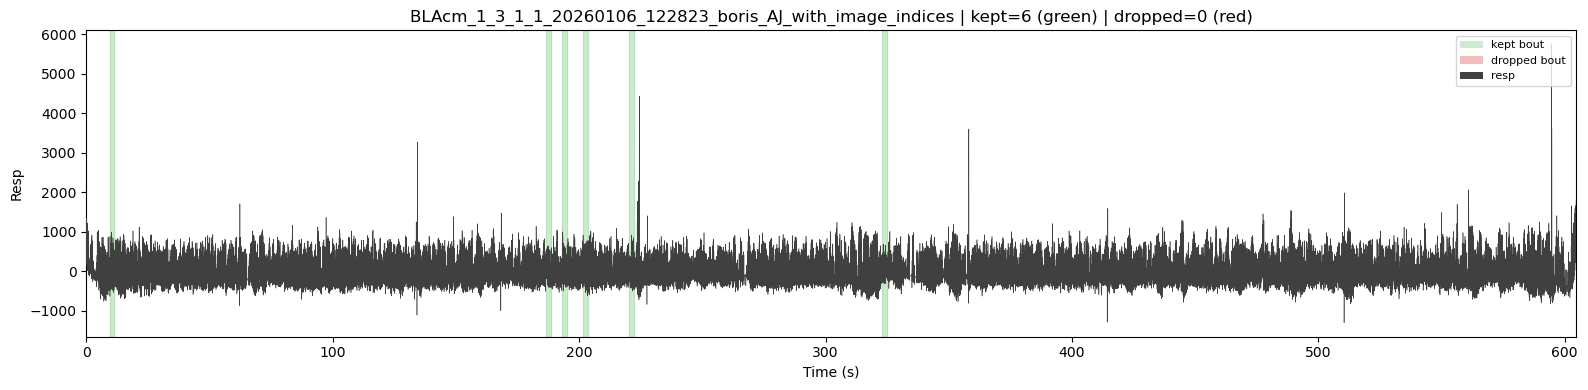


[Interaction] BLAcm_3_1_3_2_20260106_115157_BORIS_SS
  source: analog/3_1_i_cm_3_2_d_20260106_115157.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 242223
fs: 400.0
nan count: 0
inf count: 0
min/max: -2059.808715351053 3582.9341119258984
std: 366.1928217166436
first 10: [103.79944847 103.66809743 107.63753852 118.80571555 139.15063328
 169.55714357 209.91317192 259.21612551 315.69784547 376.96412095]
  ✓ 4602 breaths detected


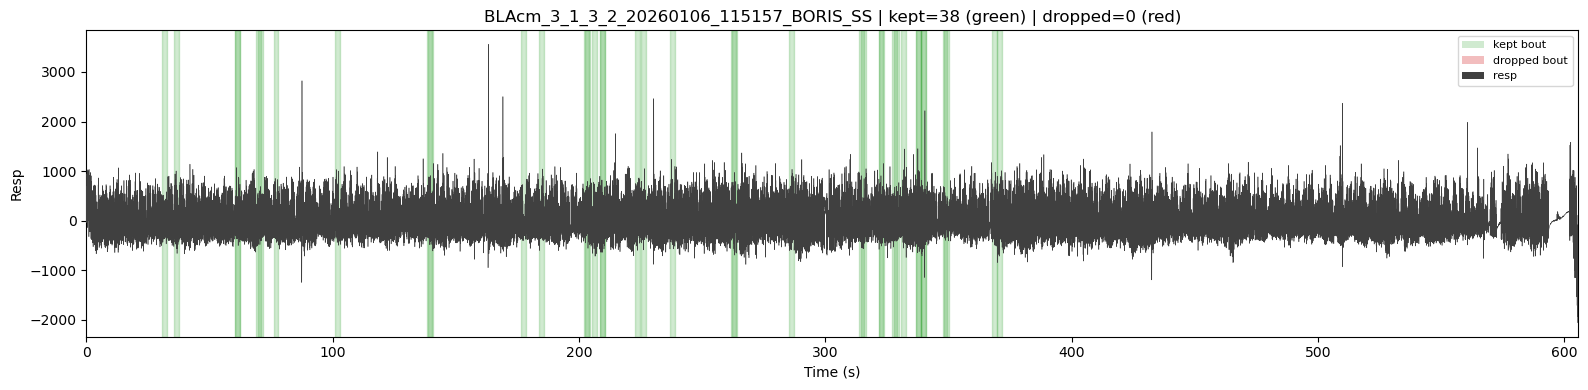


[Interaction] BLAcm_3_1_3_3_20260107_123230_BORIS_SS
  source: analog/3_1_i_cm_3_3_s_20260107_123230.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 242084
fs: 400.0
nan count: 0
inf count: 0
min/max: -635.9013326667645 2145.724495986516
std: 192.95521289532684
first 10: [234.48216379 248.37222327 264.0254843  283.3444823  307.99633425
 339.30797448 378.1840721  425.06054308 479.8886869  542.14638478]
  ✓ 3886 breaths detected


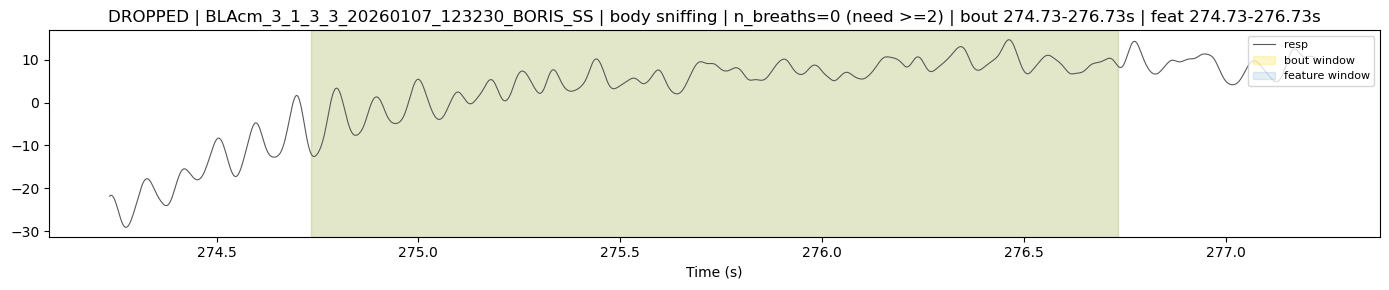

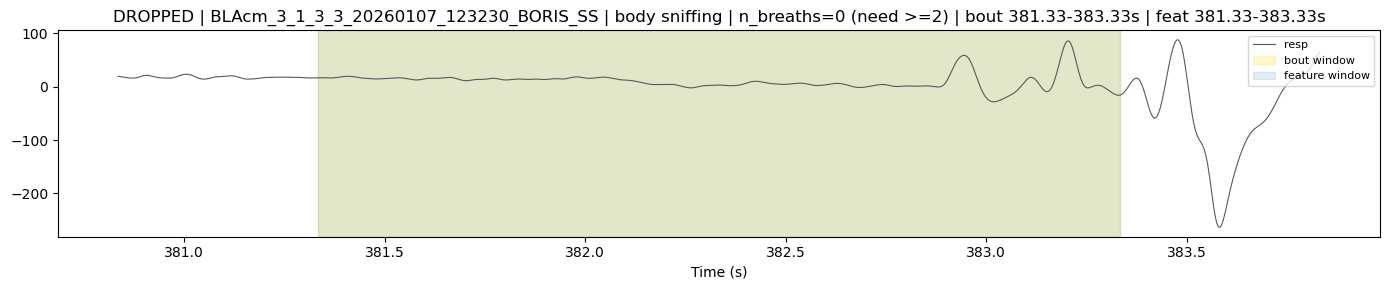

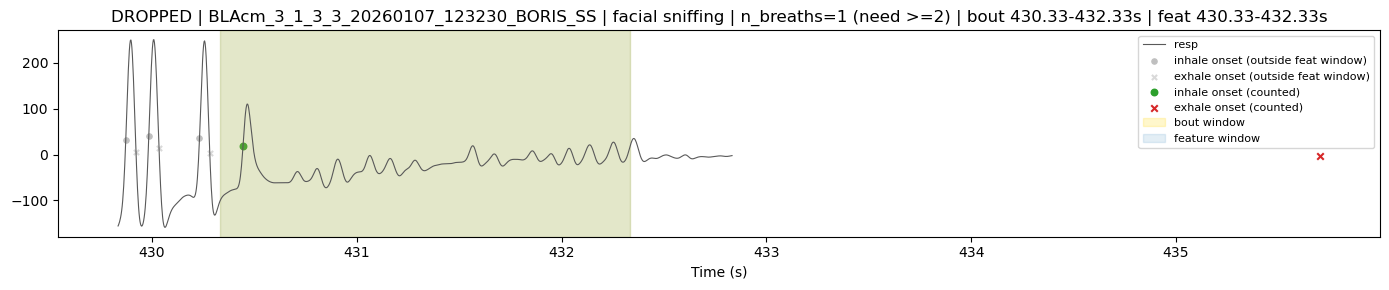

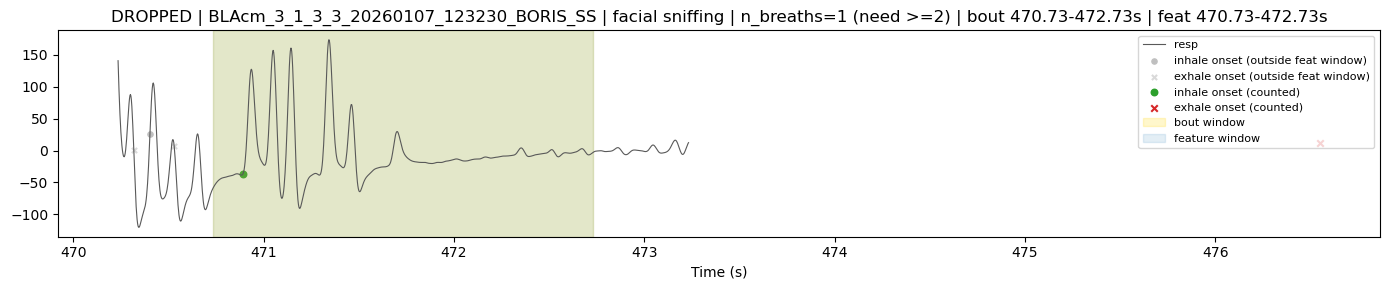

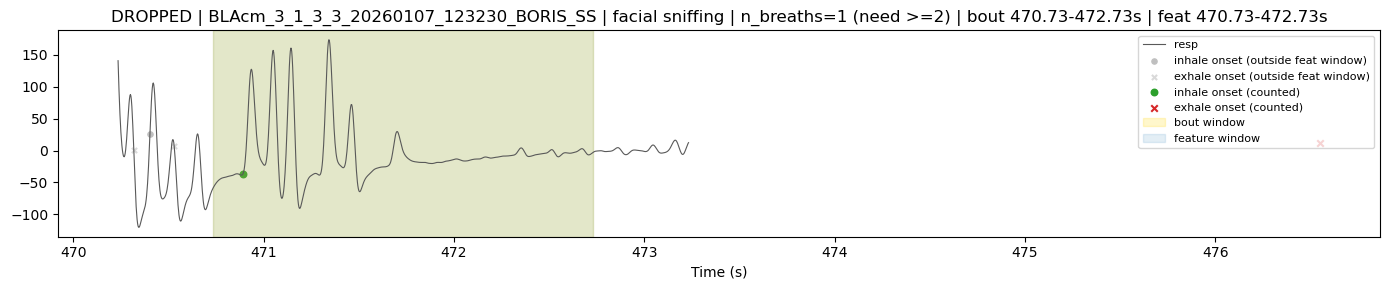

  → Dropped 6 bouts (<2 breaths in feature window); plotted 5


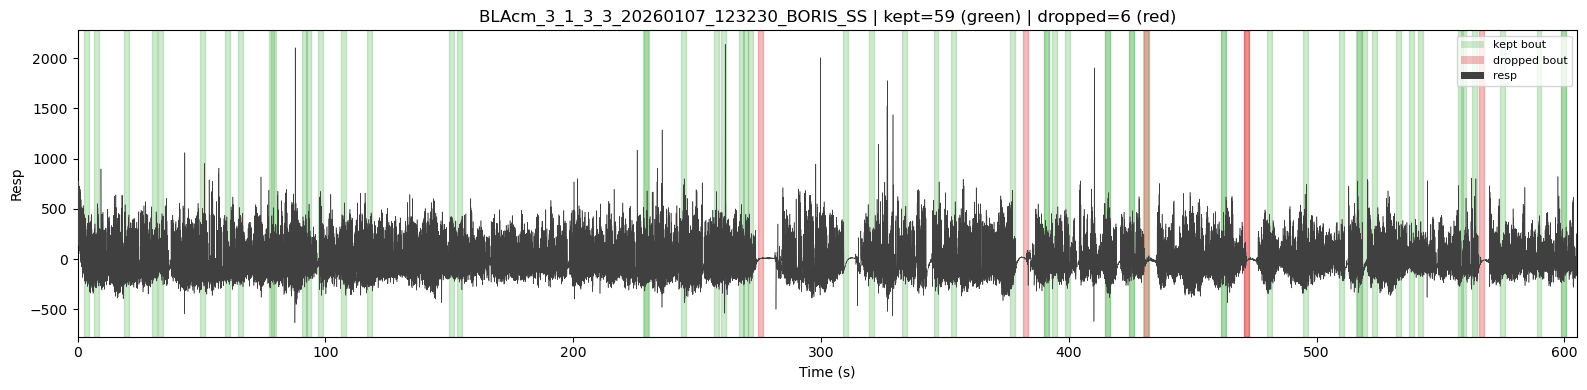


[Interaction] BLAcm_4_1_4_2_20260107_160439_VT_CM
  source: analog/4_1_s_cm_4_2_d_20260107_160439.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 244523
fs: 400.0
nan count: 0
inf count: 0
min/max: -1102.6285628337894 4366.2649655177365
std: 278.71153243295345
first 10: [-156.47342377 -161.48981141 -170.3148224  -185.16303226 -206.60511254
 -233.94798945 -265.68261788 -299.84774057 -334.31037702 -366.96640421]
  ✓ 3851 breaths detected


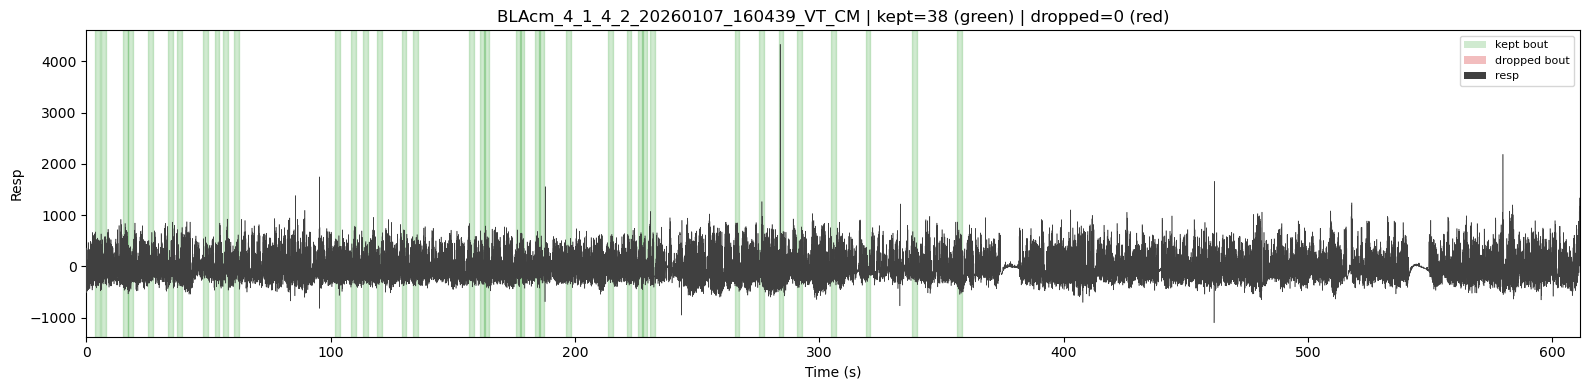


[Interaction] BLAcm_4_1_4_2_20260107_160439_VT_SA
  source: analog/4_1_s_cm_4_2_d_20260107_160439.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 244523
fs: 400.0
nan count: 0
inf count: 0
min/max: -1102.6285628337894 4366.2649655177365
std: 278.71153243295345
first 10: [-156.47342377 -161.48981141 -170.3148224  -185.16303226 -206.60511254
 -233.94798945 -265.68261788 -299.84774057 -334.31037702 -366.96640421]
  ✓ 3851 breaths detected


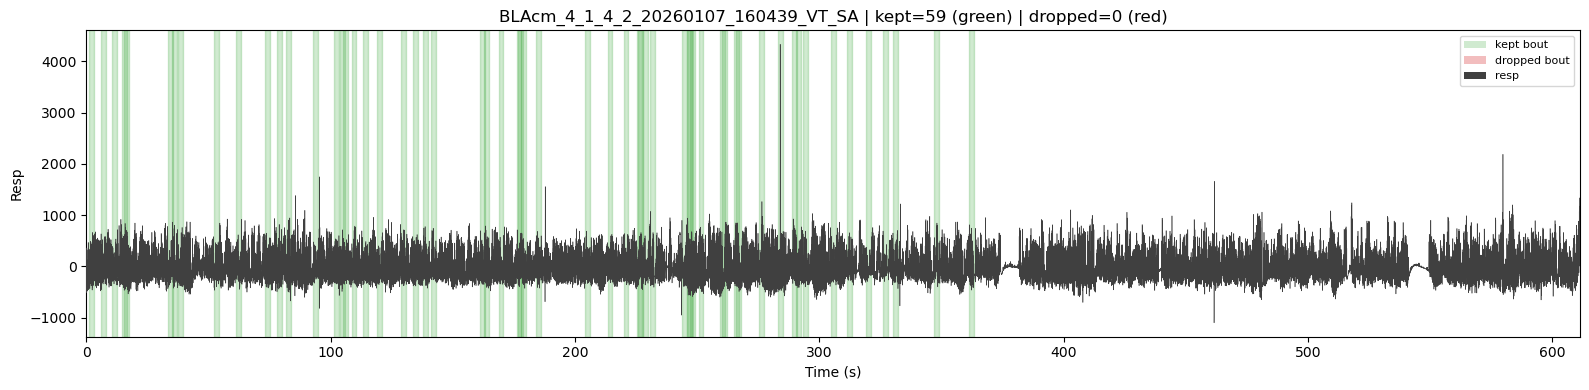


[Interaction] BLAcm_4_2_4_1_20260107_150836_VT_CM
  source: analog/4_2_d_cm_4_1_s_20260107_150836.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 243387
fs: 400.0
nan count: 0
inf count: 0
min/max: -1244.1538523524912 6915.012893544908
std: 343.33565210833024
first 10: [ -28.57282804  -46.37328299  -65.93638627  -87.56784174 -110.4262241
 -132.85009776 -152.71225747 -167.69863053 -175.53240671 -174.15438348]
  ✓ 3963 breaths detected


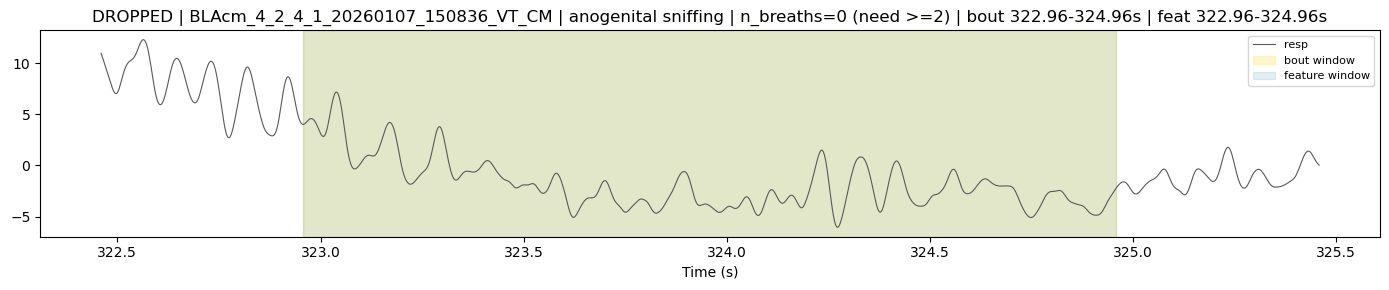

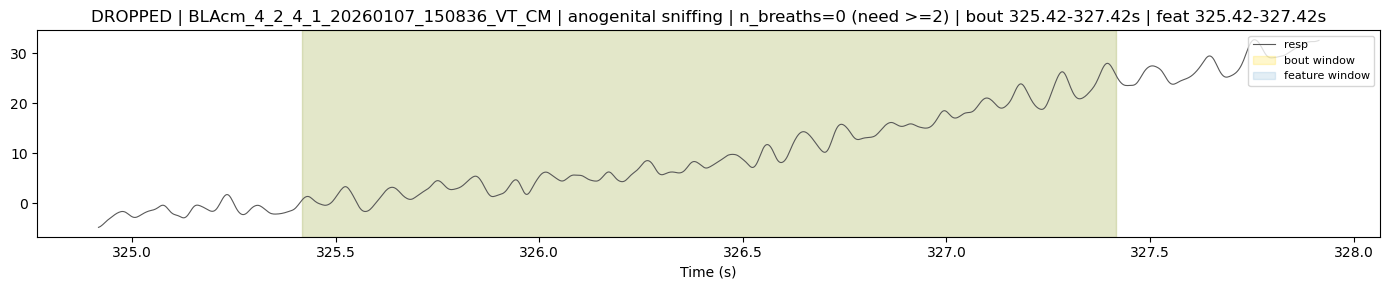

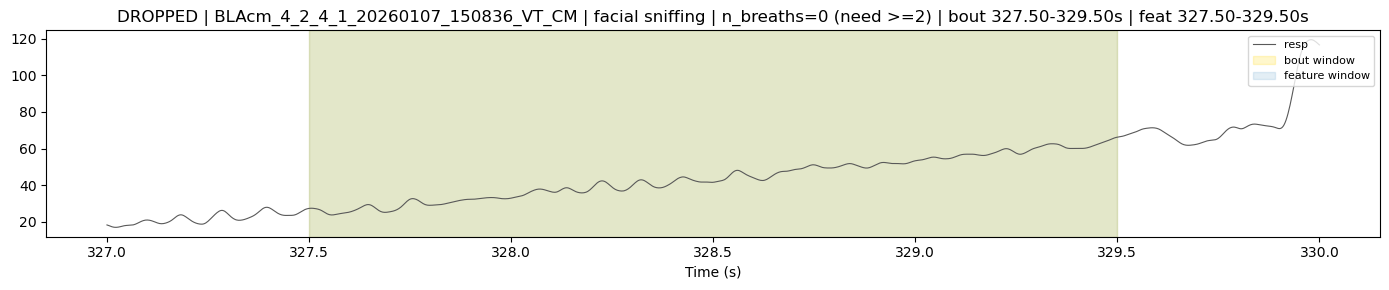

  → Dropped 3 bouts (<2 breaths in feature window); plotted 3


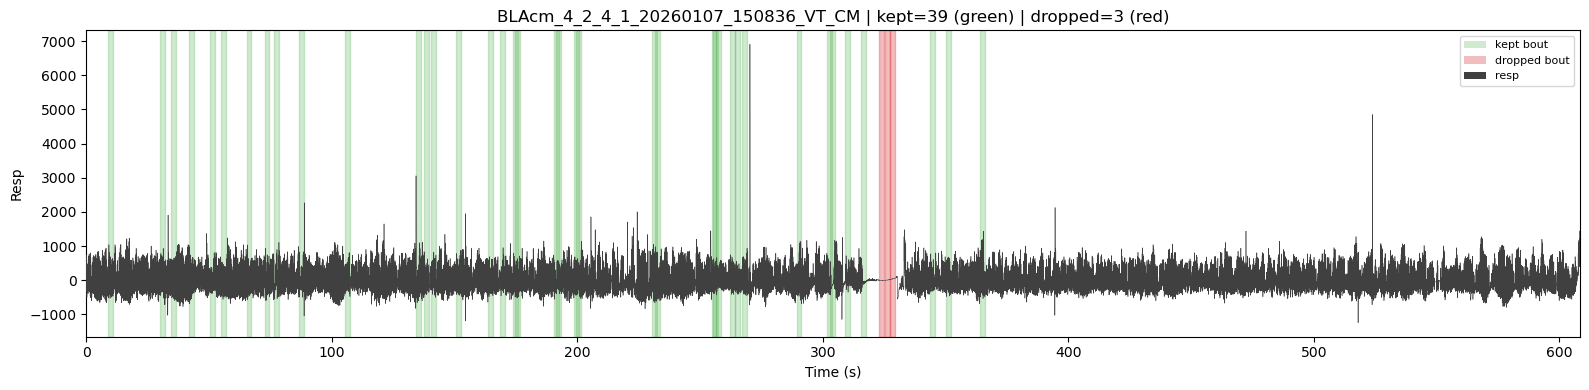


[Interaction] BLAcm_4_2_4_1_20260107_150836_VT_SA
  source: analog/4_2_d_cm_4_1_s_20260107_150836.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 243387
fs: 400.0
nan count: 0
inf count: 0
min/max: -1244.1538523524912 6915.012893544908
std: 343.33565210833024
first 10: [ -28.57282804  -46.37328299  -65.93638627  -87.56784174 -110.4262241
 -132.85009776 -152.71225747 -167.69863053 -175.53240671 -174.15438348]
  ✓ 3963 breaths detected


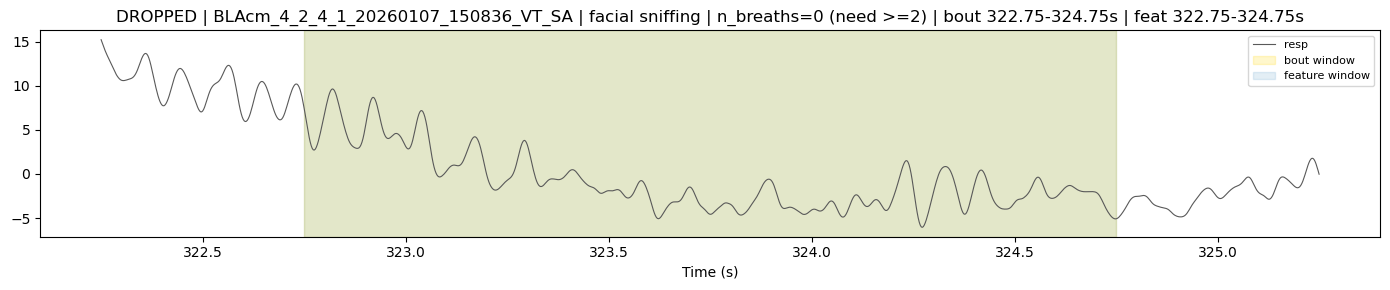

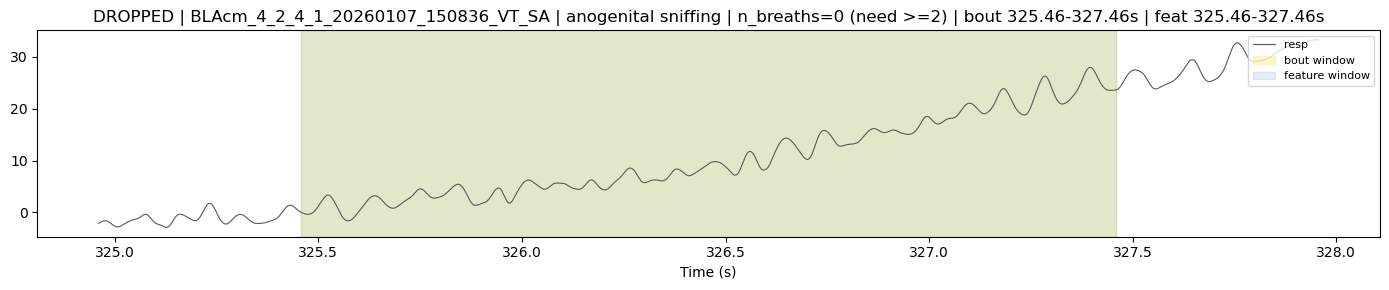

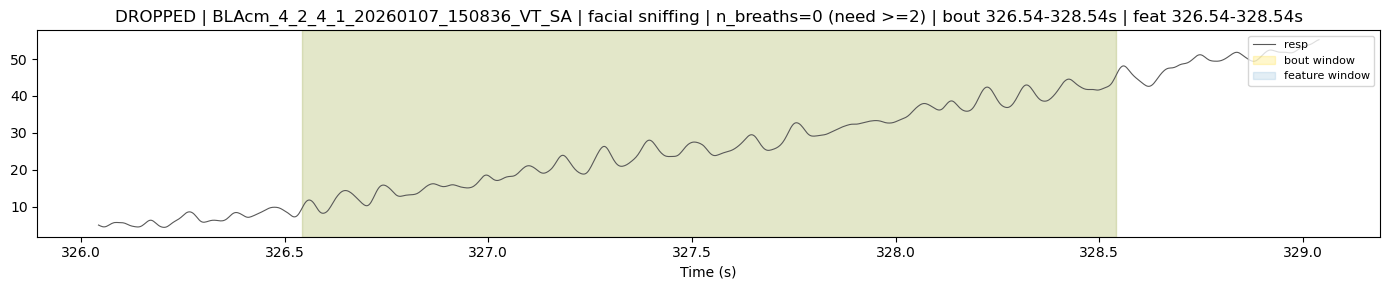

  → Dropped 3 bouts (<2 breaths in feature window); plotted 3


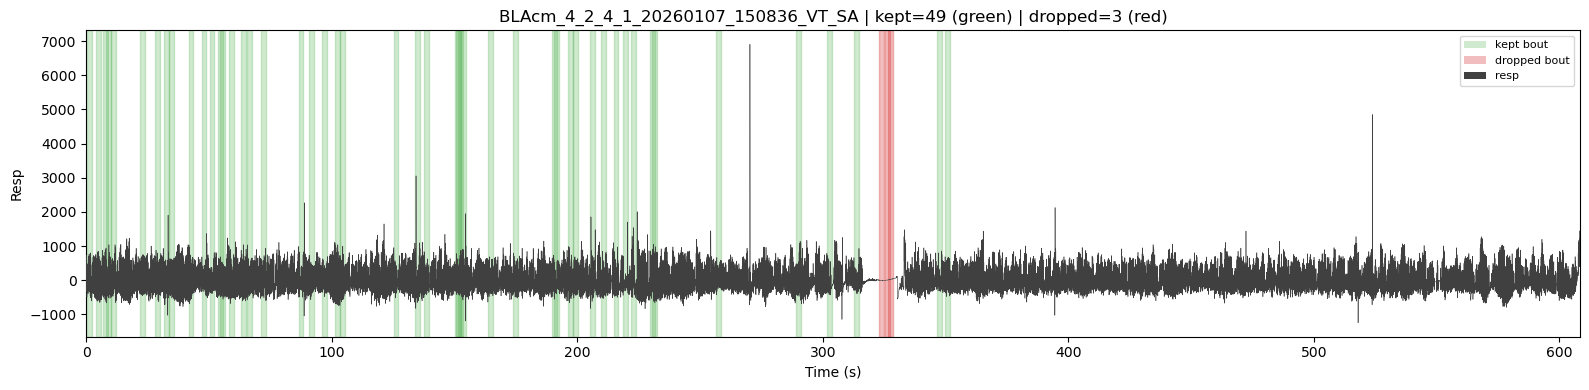


[Interaction] BLAcm_7_1_7_2_20260106_111330_BORIS
  source: analog/7_1_d_cm_7_2_s_20260106_111330.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 245410
fs: 400.0
nan count: 0
inf count: 0
min/max: -1387.1993838717272 6380.326643074468
std: 460.99517105379095
first 10: [ 466.93908891  655.5630502   840.34231592 1017.09952699 1182.03871321
 1331.60498543 1462.43791861 1571.44249209 1655.93436031 1713.82098304]
  ✓ 3917 breaths detected


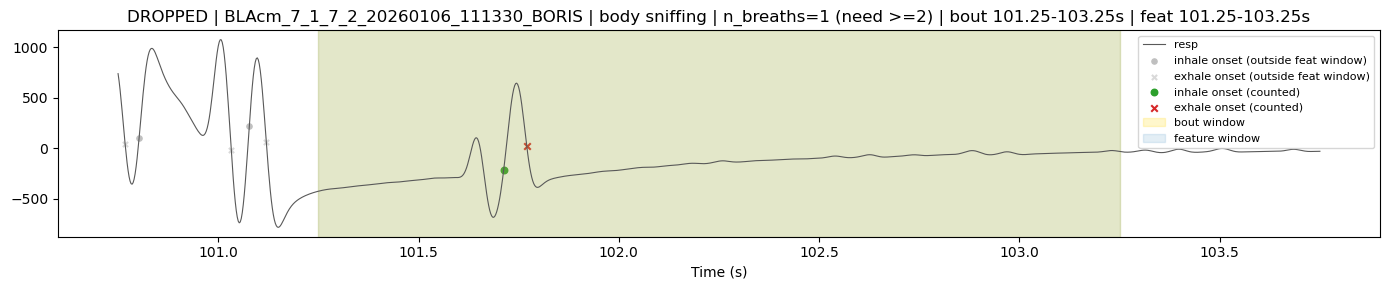

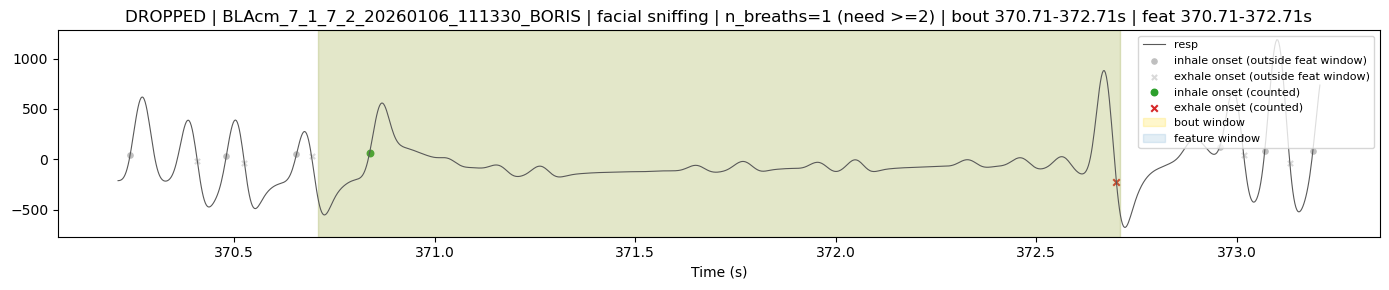

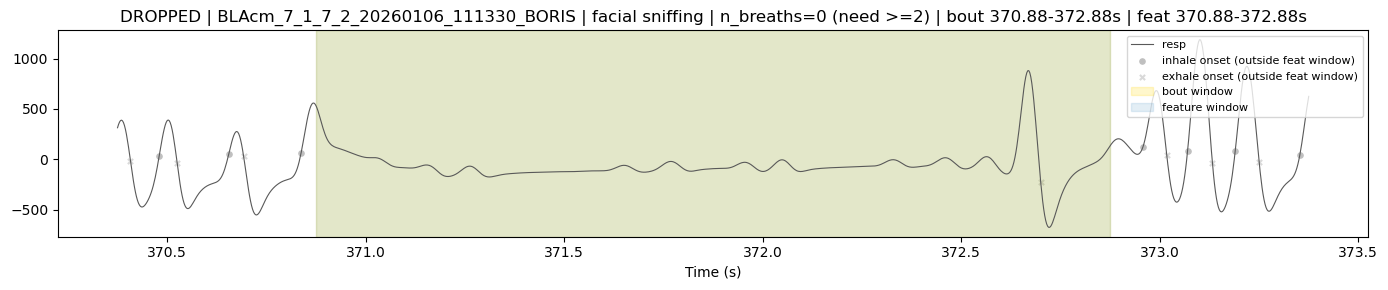

  → Dropped 3 bouts (<2 breaths in feature window); plotted 3


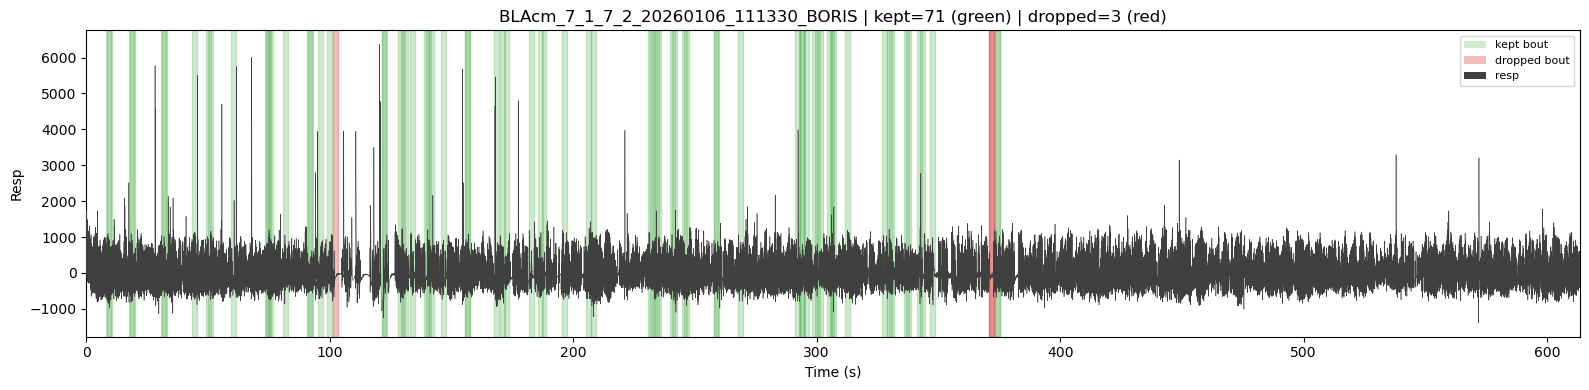


[Interaction] BLAcm_7_2_7_1_20260106_130431_BORIS_SS
  source: analog/7_2_s_cm_7_1_d_20260106_130431.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 244983
fs: 400.0
nan count: 0
inf count: 0
min/max: -1193.4503798657995 4793.5256015132345
std: 355.0320553088223
first 10: [-116.52501059 -144.22476933 -170.33745846 -193.09109477 -211.1576006
 -223.51396751 -229.2959294  -227.6965094  -217.91163359 -199.13836755]
  ✓ 3578 breaths detected


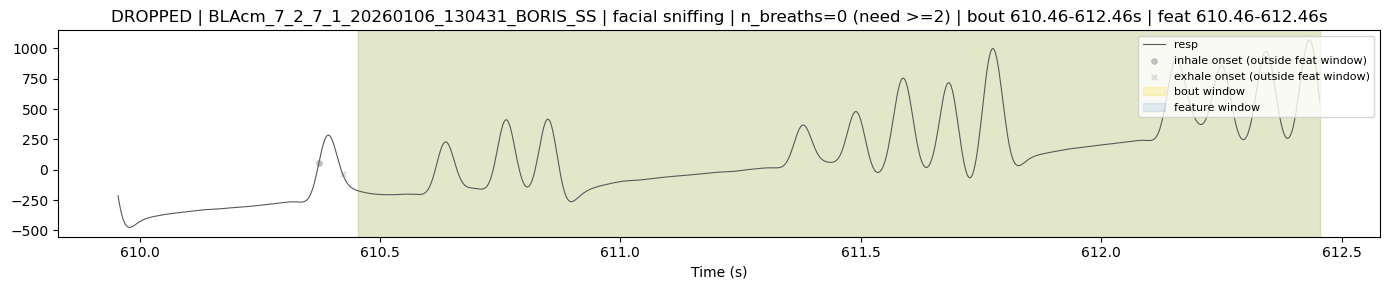

  → Dropped 1 bouts (<2 breaths in feature window); plotted 1


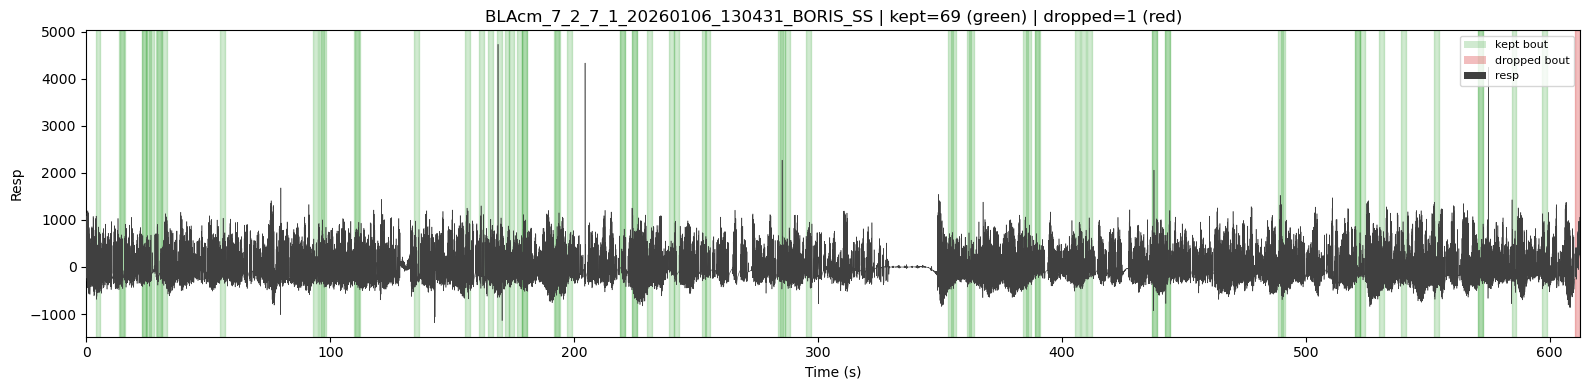


[Interaction] BLAcm_8_1_8_2_20260107_152812_VT_CM
  source: analog/8_1_s_cm_8_2_d_20260107_152812.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 243997
fs: 400.0
nan count: 0
inf count: 0
min/max: -1398.0841374041615 4889.174832241604
std: 336.7888780791369
first 10: [ 200.20923375  364.24316661  519.92320279  660.04919958  779.55052243
  875.18673781  945.17195294  988.88516746 1006.64869961  999.56426659]
  ✓ 3370 breaths detected


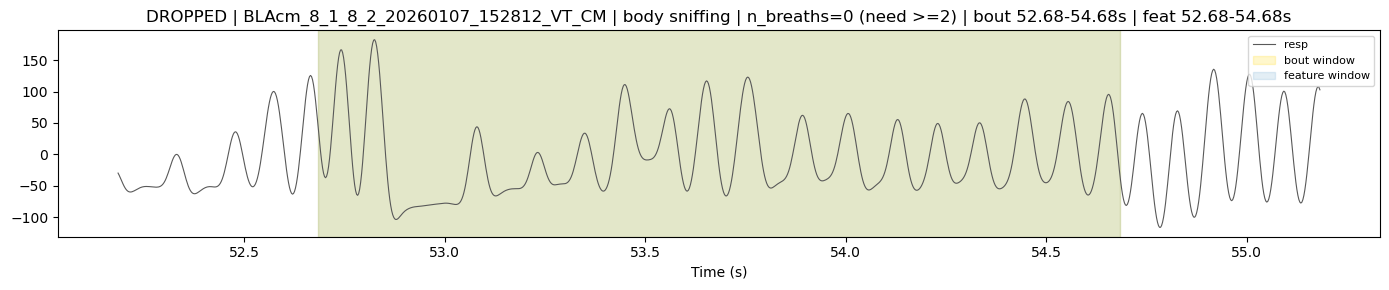

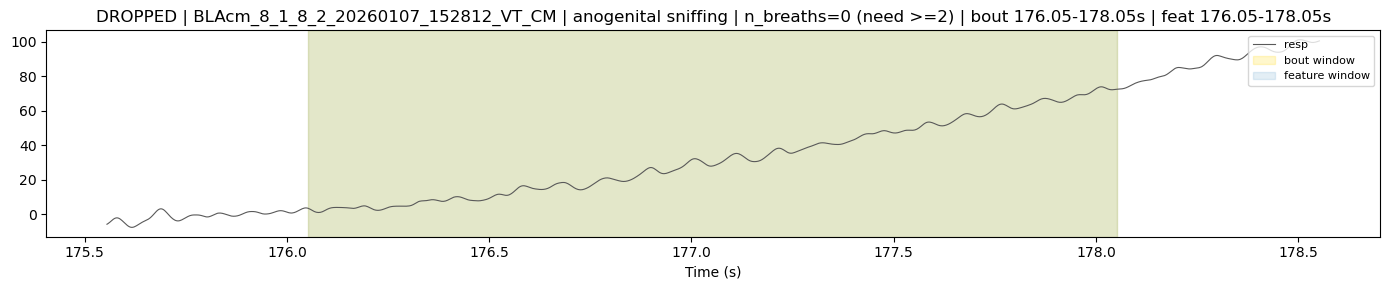

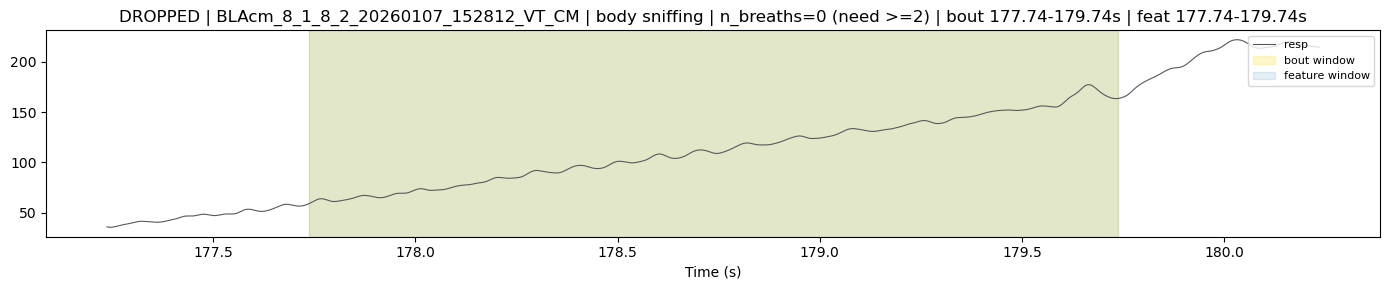

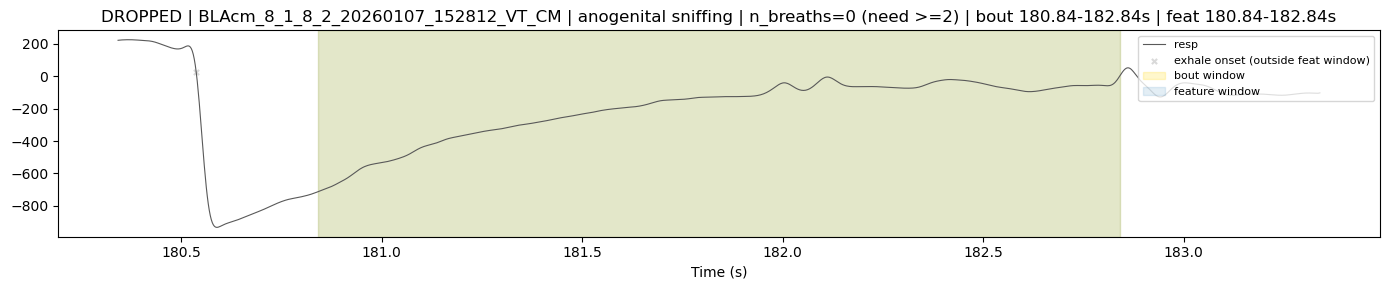

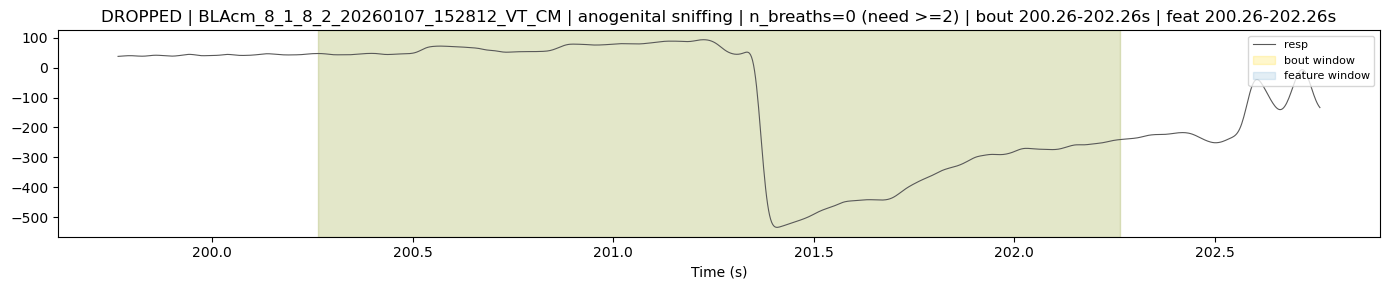

  → Dropped 11 bouts (<2 breaths in feature window); plotted 5


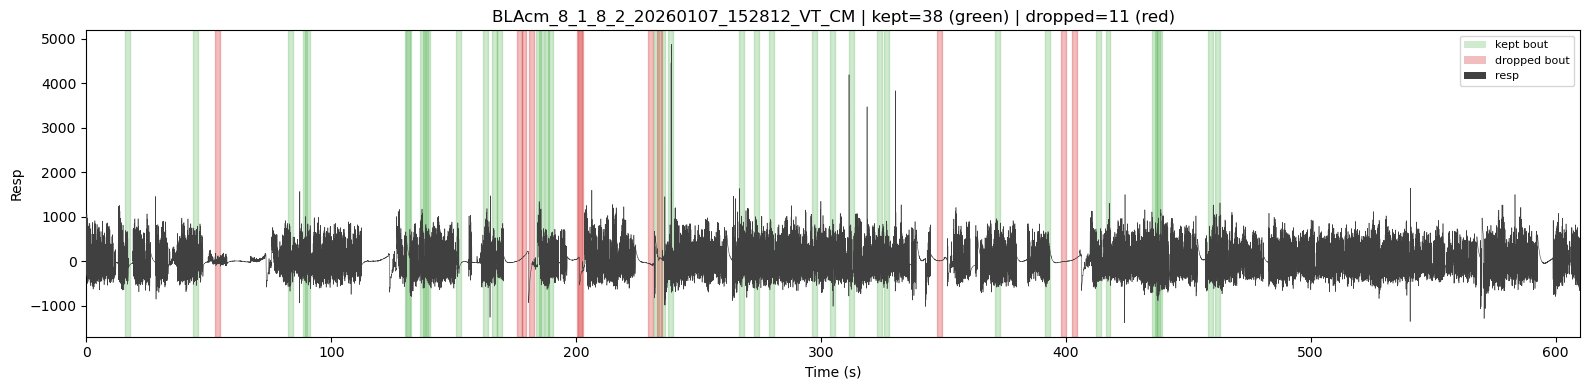


[Interaction] BLAcm_8_1_8_2_20260107_152812_VT_SA
  source: analog/8_1_s_cm_8_2_d_20260107_152812.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 243997
fs: 400.0
nan count: 0
inf count: 0
min/max: -1398.0841374041615 4889.174832241604
std: 336.7888780791369
first 10: [ 200.20923375  364.24316661  519.92320279  660.04919958  779.55052243
  875.18673781  945.17195294  988.88516746 1006.64869961  999.56426659]
  ✓ 3370 breaths detected


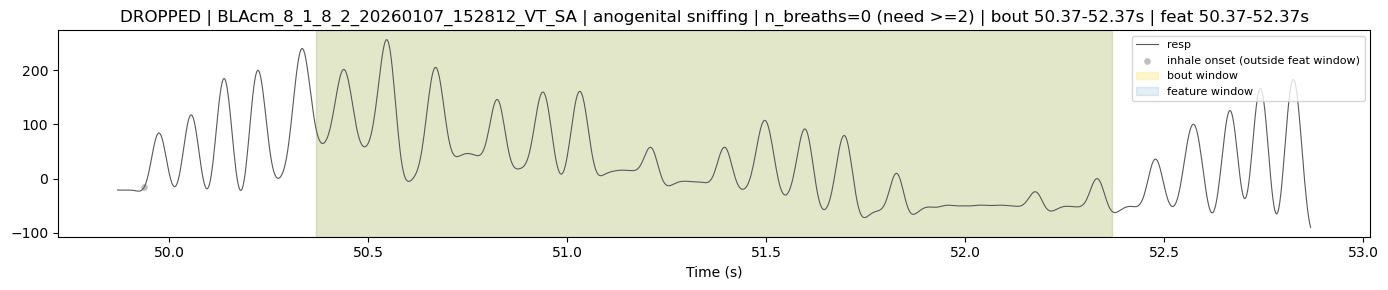

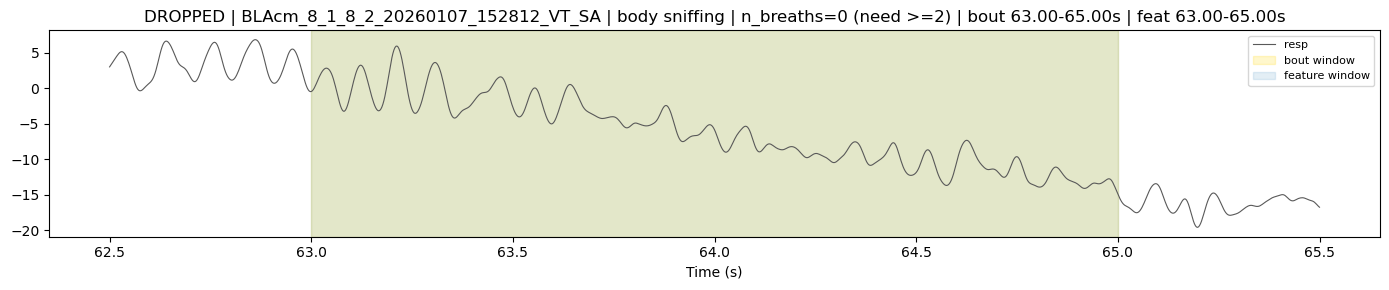

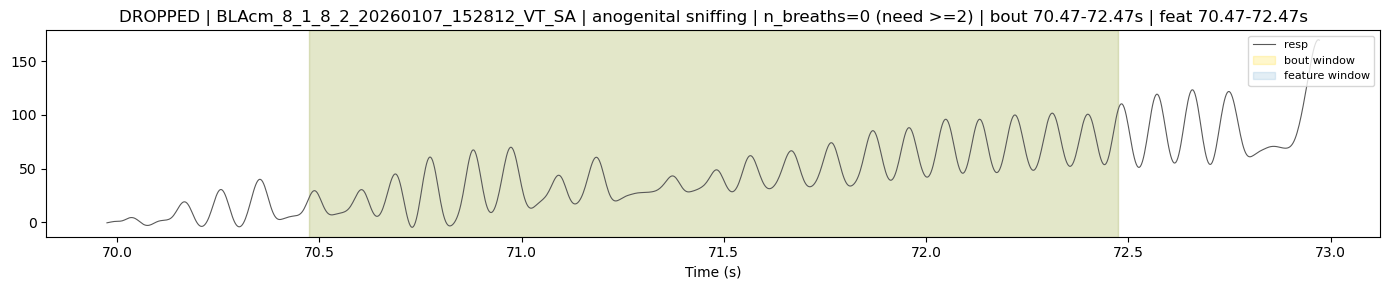

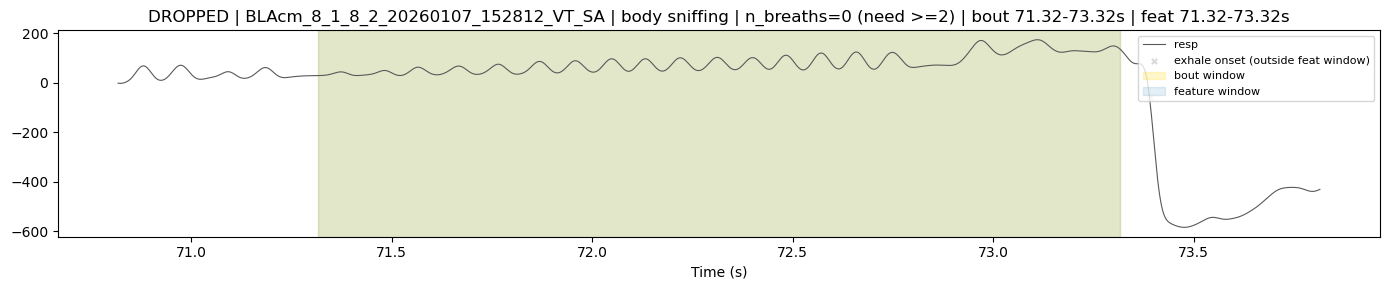

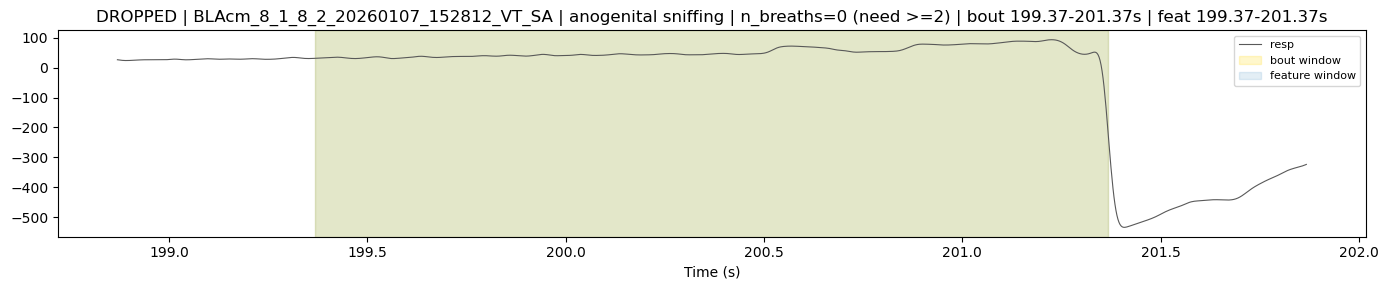

  → Dropped 12 bouts (<2 breaths in feature window); plotted 5


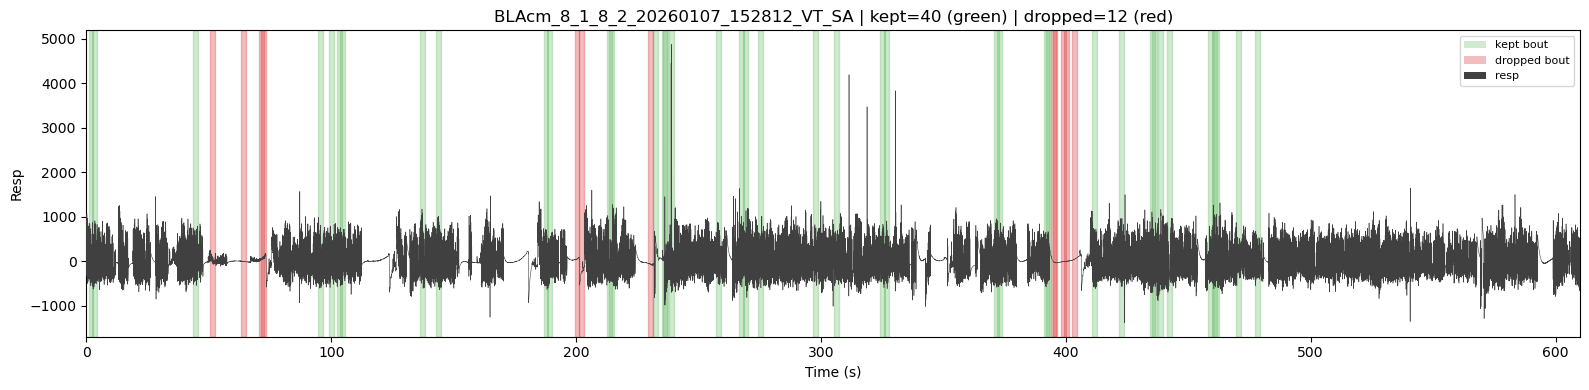


[Interaction] BLAcm_8_2_8_1_20260106_113241_BORIS_SS
  source: analog/8_2_s_cm_8_1_d_20260106_113241.analog_ECU_Ain1 @ 20000.0 Hz -> 400.0 Hz
signal len: 245189
fs: 400.0
nan count: 0
inf count: 0
min/max: -1471.3787739409233 2028.7172149612545
std: 342.88883871715257
first 10: [ 248.51491547  379.75778364  506.16362239  623.38005889  728.27836812
  818.75133006  893.46664493  951.67421108  993.06080597 1017.64818554]
  ✓ 4382 breaths detected


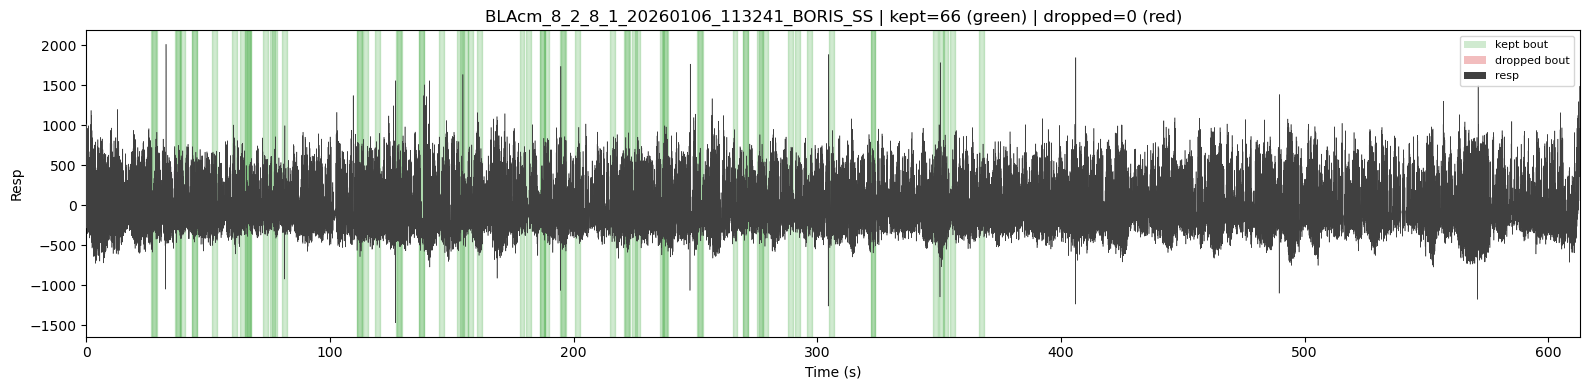


Feature matrix: 1153 rows × 46 cols
   Trials    : 23
   Subjects  : 15
   Type dist :
Type
Interaction    1153
Name: count, dtype: int64
   Initiator dist :
Initiator
social_agent    644
subject         509
Name: count, dtype: int64


In [83]:
# Merge BLA rank annotations into aim1_rank_map
for subj_id, rnk in bla_aim1_rank_map.items():
    if subj_id in aim1_rank_map and aim1_rank_map[subj_id] != rnk:
        print(f"  Rank conflict for {subj_id}: {aim1_rank_map[subj_id]} vs {rnk}; using {rnk}")
    aim1_rank_map[subj_id] = rnk

print(f"\nBLA cm trials added: {len(resp_paths_cm_bla)} (resp) / {len(boris_paths_cm_bla)} (boris)")
print(f"Total interaction trials (AIM1+BLA): {len(resp_paths_interactions)}")

# --- Upstream filter: skip subjects/trials flagged in BORIS EDA ---
resp_paths_for_bm, boris_paths_for_bm, _dropped_upstream = filter_interaction_paths(
    resp_paths_interactions,
    boris_paths_interactions,
    exclude_subjects_by_cohort=exclude_subjects_by_cohort,
    exclude_trials=exclude_trials_upstream,
)
print(
    f"Upstream exclusion: {len(resp_paths_interactions)} -> {len(resp_paths_for_bm)} trials "
    f"({len(_dropped_upstream)} skipped)"
)
for trial, reason in _dropped_upstream:
    print(f"  skip {trial} ({reason})")

boris_paths_valence = boris_paths_for_bm

# --- Build feature matrix (2s onset-anchored windows) ---
# Set plot_dropped_bouts=True to inspect bouts dropped for insufficient breaths
master_df = build_feature_matrix(
    resp_paths_interactions = resp_paths_for_bm,
    boris_paths_valence     = boris_paths_for_bm,
    aim1_rank_map                = aim1_rank_map,
    target_dur              = 2.0,
    min_dur                 = 0.5,
    pre_bout_window         = 2.0,
    bout_anchor             = "onset",
    data_type               = "rodentAirflow",
    target_srate            = 400,
    min_breaths_per_bout    = 2,
    plot_dropped_bouts      = True,
    max_dropped_plots_per_trial = 5,
    plot_session_overview   = True,
)

# Interactions only (no BLRI baseline pseudo-bouts)
master_df = master_df[master_df["Type"] == "Interaction"].reset_index(drop=True)
master_df = add_engineered_features(master_df)


In [84]:
# Confirm all windows are ~3 s interaction bouts
print(master_df["Duration"].describe())
print("\nInteraction windows:", len(master_df))
print("Trials:", master_df["Trial"].nunique())
print("Subjects:", master_df["Subject"].nunique())
print("Behavior counts:\n", master_df["Behavior"].value_counts())
print("Feature cols:", [c for c in master_df.columns if c not in
    ["BoutID","Behavior","Initiator","Start","Stop","Duration",
     "PreBoutRespRate","Trial","Subject","social_agent","Cohort","Rank",
     "Type","h5_path","h5_filename","boris_path","boris_filename","FeatureWindow",
     "resp_rate_delta","breathing_rate_z"]])

count    1.153000e+03
mean     2.000000e+00
std      2.306340e-15
min      2.000000e+00
25%      2.000000e+00
50%      2.000000e+00
75%      2.000000e+00
max      2.000000e+00
Name: Duration, dtype: float64

Interaction windows: 1153
Trials: 23
Subjects: 15
Behavior counts:
 Behavior
facial sniffing        731
body sniffing          277
anogenital sniffing    145
Name: count, dtype: int64
Feature cols: ['n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_ibi', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol_proxy', 'cv_inhale_vol', 'ventilation_proxy', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle', 'exhale_duty_cycle', 'vol_asym

## Respiration & Behavior Alignment Done - Feature Matrix Made

---

## Feature Matrix Inspection - Dropping Bad Recordings

Bad recordings / subjects (see **Behavior Inspection** below):
- Sparse behavior per recording → whole subject dropped (`min_windows=10`)
- Missing BORIS for any indexed trial → whole subject dropped
- Aim1 fighting sessions for 1_1, 1_2 → whole subject dropped
- Duplicate VT_CM + VT_SA BORIS exports → keep VT_SA trial per H5 (same as Sequoia concat intent)

In [85]:
master_df.head()

,Behavior,Initiator,Start,Stop,Duration,PreBoutRespRate,Trial,Subject,social_agent,Cohort,Rank,Type,h5_path,h5_filename,boris_path,boris_filename,FeatureWindow,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_ibi,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,...,mean_inhale_pause_dur_sec_z_trial,cv_inhale_pause_dur_z_subject,cv_inhale_pause_dur_z_trial,inhale_pause_duty_cycle_z_subject,inhale_pause_duty_cycle_z_trial,pct_breaths_with_exhale_pause_z_subject,pct_breaths_with_exhale_pause_z_trial,mean_exhale_pause_dur_sec_z_subject,mean_exhale_pause_dur_sec_z_trial,cv_exhale_pause_dur_z_subject,cv_exhale_pause_dur_z_trial,exhale_pause_duty_cycle_z_subject,exhale_pause_duty_cycle_z_trial,inhale_duty_cycle_z_subject,inhale_duty_cycle_z_trial,exhale_duty_cycle_z_subject,exhale_duty_cycle_z_trial,resp_rate_delta_z_subject,resp_rate_delta_z_trial,breathing_rate_z_z_subject,breathing_rate_z_z_trial,vol_asymmetry_z_subject,vol_asymmetry_z_trial,peak_flow_ratio_z_subject,peak_flow_ratio_z_trial
0,facial sniffing,social_agent,17.867,19.867,2.0,8.751609,AIM1cm_1_1_1_2_20250623_111352,1_1,1_2,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352.1.csv,full,15,7.766990,0.128750,0.147103,0.056500,0.096672,0.067833,0.247365,...,-0.235702,NaN,NaN,-0.124613,-0.235702,-0.45421,-0.510664,-0.338116,-0.498326,NaN,NaN,-0.275613,-0.50422,-0.140057,-0.548873,0.407782,0.674258,-0.435705,-0.568471,1.061573,1.054472,-0.420154,-0.804933,-1.555952,-0.667764
1,facial sniffing,subject,18.200,20.200,2.0,8.476821,AIM1cm_1_1_1_2_20250623_111352,1_1,1_2,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352.1.csv,full,15,7.349081,0.136071,0.112555,0.059667,0.089036,0.071000,0.211580,...,-0.235702,NaN,NaN,-0.124613,-0.235702,-0.45421,-0.510664,-0.338116,-0.498326,NaN,NaN,-0.275613,-0.50422,-0.141162,-0.558124,0.354651,0.524540,-0.500139,-0.666460,0.560362,0.556614,-0.436476,-0.971947,-1.691629,-1.078556
2,facial sniffing,social_agent,113.767,115.767,2.0,6.857143,AIM1cm_1_1_1_2_20250623_111352,1_1,1_2,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352.1.csv,full,16,7.812500,0.128000,0.156770,0.059063,0.119605,0.063125,0.305330,...,-0.235702,NaN,NaN,-0.124613,-0.235702,-0.45421,-0.510664,-0.338116,-0.498326,NaN,NaN,-0.275613,-0.50422,-0.066588,0.066276,0.055077,-0.319630,0.437692,0.759757,1.116154,1.108688,-0.217474,1.269016,-0.973565,1.095552
3,facial sniffing,subject,196.467,198.467,2.0,5.056890,AIM1cm_1_1_1_2_20250623_111352,1_1,1_2,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352.1.csv,full,14,7.355021,0.135962,0.146665,0.065000,0.148961,0.068214,0.236473,...,-0.235702,NaN,NaN,-0.124613,-0.235702,-0.45421,-0.510664,-0.338116,-0.498326,NaN,NaN,-0.275613,-0.50422,-0.012439,0.519672,0.144606,-0.067345,1.042223,1.679103,0.567486,0.563690,-0.195190,1.497039,-0.696521,1.934367
4,body sniffing,subject,218.467,220.467,2.0,7.418856,AIM1cm_1_1_1_2_20250623_111352,1_1,1_2,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352.1.csv,full,14,6.869221,0.145577,0.183129,0.064821,0.267388,0.074821,0.305573,...,-0.235702,NaN,NaN,-0.124613,-0.235702,-0.45421,-0.510664,-0.338116,-0.498326,NaN,NaN,-0.275613,-0.50422,-0.119120,-0.373573,0.272800,0.293892,-0.239871,-0.270654,-0.015149,-0.015048,-0.402598,-0.625290,-1.650442,-0.953853


In [86]:
nan_counts = master_df.isna().sum()
nan_pct = master_df.isna().mean() * 100

nan_summary = pd.DataFrame({
    "nan_count": nan_counts,
    "nan_percent": nan_pct
}).sort_values(by="nan_percent", ascending=False)

nan_summary.head(10)

,nan_count,nan_percent
cv_inhale_pause_dur,1148,99.566349
cv_inhale_pause_dur_z_subject,1148,99.566349
cv_inhale_pause_dur_z_trial,1148,99.566349
cv_exhale_pause_dur_z_trial,1071,92.888118
cv_exhale_pause_dur_z_subject,1069,92.714657
cv_exhale_pause_dur,1066,92.454467
Rank,97,8.412836
inhale_pause_duty_cycle_z_subject,31,2.688638
mean_inhale_pause_dur_sec_z_trial,31,2.688638
mean_inhale_pause_dur_sec_z_subject,31,2.688638


### Dropping bad recording | no behavior

In [87]:
# RI1_3_5
master_df = master_df[master_df["Trial"] != "RI1_3_5"]

# Drop any windows where we couldn't determine a rank label.
# (e.g., cagemate BLA recordings with role 'i' or any unexpected filename.)
master_df = master_df[master_df["Rank"].notna()].copy()

master_df["Trial"].unique()

array(['AIM1cm_1_1_1_2_20250623_111352', 'AIM1cm_2_3_2_4_20250623_151153',
       'AIM1cm_2_4_2_3_20250623_143348', 'AIM1cm_3_5_3_6_20250623_160001',
       'AIM1cm_4_7_4_8_20250623_193718', 'AIM1cm_4_8_4_7_20250623_182649',
       'BLAcm_1_1_1_2_20260106_134350_BORIS_SS',
       'BLAcm_1_1_1_3_20260107_163611_VT_CM',
       'BLAcm_1_1_1_3_20260107_163611_VT_SA',
       'BLAcm_1_2_1_3_20260108_114416_VT_CM',
       'BLAcm_1_2_1_3_20260108_114416_VT_SA',
       'BLAcm_1_3_1_1_20260106_122823_boris_AJ_with_image_indices',
       'BLAcm_4_1_4_2_20260107_160439_VT_CM',
       'BLAcm_4_1_4_2_20260107_160439_VT_SA',
       'BLAcm_4_2_4_1_20260107_150836_VT_CM',
       'BLAcm_4_2_4_1_20260107_150836_VT_SA',
       'BLAcm_7_1_7_2_20260106_111330_BORIS',
       'BLAcm_7_2_7_1_20260106_130431_BORIS_SS',
       'BLAcm_8_1_8_2_20260107_152812_VT_CM',
       'BLAcm_8_1_8_2_20260107_152812_VT_SA',
       'BLAcm_8_2_8_1_20260106_113241_BORIS_SS'], dtype=object)

### Subject balance (dedupe + filter)


In [88]:
# --- Subject balance: dedupe duplicate BORIS exports, filter sparse subjects ---
def dedupe_h5_boris_exports(df, prefer_tag="VT_SA"):
    if "h5_path" not in df.columns:
        return df.copy(), []
    inter = df[df["Type"] == "Interaction"].copy()
    drop_trials = []
    keep_mask = pd.Series(True, index=df.index)
    for h5, grp in inter.groupby("h5_path", observed=True):
        trials = grp["Trial"].unique()
        if len(trials) <= 1:
            continue
        tagged = [t for t in trials if prefer_tag in str(t)]
        keep_trial = tagged[0] if tagged else grp.groupby("Trial").size().idxmax()
        for t in trials:
            if t != keep_trial:
                drop_trials.append(t)
                keep_mask &= df["Trial"] != t
    return df[keep_mask].copy(), drop_trials


def audit_subject_behavior_balance(df, min_windows=10, imbalance_ratio=0.25, drop_aim1_subjects=None):
    inter = df[df["Type"] == "Interaction"].copy()
    if "Rank" in inter.columns:
        inter = inter[inter["Rank"].notna()].copy()

    trial_table = (
        inter.groupby(["Subject", "Trial", "Cohort", "Rank"], observed=True)
        .agg(n_windows=("Behavior", "size"))
        .reset_index()
        .sort_values(["Cohort", "Subject", "Trial"])
    )

    subject_rows = []
    for (cohort, subject), g in trial_table.groupby(["Cohort", "Subject"], observed=True):
        counts = g["n_windows"].to_numpy()
        subject_rows.append({
            "Cohort": cohort,
            "Subject": subject,
            "n_recordings": len(g),
            "total_windows": int(counts.sum()),
            "min_windows": int(counts.min()),
            "max_windows": int(counts.max()),
            "ratio_min_max": float(counts.min() / counts.max()) if counts.max() else np.nan,
        })
    subject_table = pd.DataFrame(subject_rows).sort_values(["Cohort", "Subject"])

    exclude_subject_cohorts = set()
    if drop_aim1_subjects:
        for subj in drop_aim1_subjects:
            if not trial_table[(trial_table["Subject"] == subj) & (trial_table["Cohort"] == "Aim1")].empty:
                exclude_subject_cohorts.add(("Aim1", subj))

    for _, row in subject_table.iterrows():
        if row["n_recordings"] > 1 and row["ratio_min_max"] < imbalance_ratio:
            exclude_subject_cohorts.add((row["Cohort"], row["Subject"]))
        if row["min_windows"] < min_windows:
            exclude_subject_cohorts.add((row["Cohort"], row["Subject"]))

    return trial_table, subject_table, sorted(exclude_subject_cohorts)


master_df_deduped, _dropped_trials = dedupe_h5_boris_exports(master_df, prefer_tag="VT_SA")
trial_balance_df, subject_balance_df, exclude_subject_cohorts = audit_subject_behavior_balance(
    master_df_deduped,
    min_windows=10,
    imbalance_ratio=0.25,
    drop_aim1_subjects=["1_1", "1_2"],
)
_exclude_pairs = set(exclude_subject_cohorts)
master_df_balanced = master_df_deduped[
    ~master_df_deduped.apply(lambda r: (r["Cohort"], r["Subject"]) in _exclude_pairs, axis=1)
].copy()

In [89]:
master_df.head()

,Behavior,Initiator,Start,Stop,Duration,PreBoutRespRate,Trial,Subject,social_agent,Cohort,Rank,Type,h5_path,h5_filename,boris_path,boris_filename,FeatureWindow,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_ibi,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,...,mean_inhale_pause_dur_sec_z_trial,cv_inhale_pause_dur_z_subject,cv_inhale_pause_dur_z_trial,inhale_pause_duty_cycle_z_subject,inhale_pause_duty_cycle_z_trial,pct_breaths_with_exhale_pause_z_subject,pct_breaths_with_exhale_pause_z_trial,mean_exhale_pause_dur_sec_z_subject,mean_exhale_pause_dur_sec_z_trial,cv_exhale_pause_dur_z_subject,cv_exhale_pause_dur_z_trial,exhale_pause_duty_cycle_z_subject,exhale_pause_duty_cycle_z_trial,inhale_duty_cycle_z_subject,inhale_duty_cycle_z_trial,exhale_duty_cycle_z_subject,exhale_duty_cycle_z_trial,resp_rate_delta_z_subject,resp_rate_delta_z_trial,breathing_rate_z_z_subject,breathing_rate_z_z_trial,vol_asymmetry_z_subject,vol_asymmetry_z_trial,peak_flow_ratio_z_subject,peak_flow_ratio_z_trial
0,facial sniffing,social_agent,17.867,19.867,2.0,8.751609,AIM1cm_1_1_1_2_20250623_111352,1_1,1_2,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352.1.csv,full,15,7.766990,0.128750,0.147103,0.056500,0.096672,0.067833,0.247365,...,-0.235702,NaN,NaN,-0.124613,-0.235702,-0.45421,-0.510664,-0.338116,-0.498326,NaN,NaN,-0.275613,-0.50422,-0.140057,-0.548873,0.407782,0.674258,-0.435705,-0.568471,1.061573,1.054472,-0.420154,-0.804933,-1.555952,-0.667764
1,facial sniffing,subject,18.200,20.200,2.0,8.476821,AIM1cm_1_1_1_2_20250623_111352,1_1,1_2,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352.1.csv,full,15,7.349081,0.136071,0.112555,0.059667,0.089036,0.071000,0.211580,...,-0.235702,NaN,NaN,-0.124613,-0.235702,-0.45421,-0.510664,-0.338116,-0.498326,NaN,NaN,-0.275613,-0.50422,-0.141162,-0.558124,0.354651,0.524540,-0.500139,-0.666460,0.560362,0.556614,-0.436476,-0.971947,-1.691629,-1.078556
2,facial sniffing,social_agent,113.767,115.767,2.0,6.857143,AIM1cm_1_1_1_2_20250623_111352,1_1,1_2,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352.1.csv,full,16,7.812500,0.128000,0.156770,0.059063,0.119605,0.063125,0.305330,...,-0.235702,NaN,NaN,-0.124613,-0.235702,-0.45421,-0.510664,-0.338116,-0.498326,NaN,NaN,-0.275613,-0.50422,-0.066588,0.066276,0.055077,-0.319630,0.437692,0.759757,1.116154,1.108688,-0.217474,1.269016,-0.973565,1.095552
3,facial sniffing,subject,196.467,198.467,2.0,5.056890,AIM1cm_1_1_1_2_20250623_111352,1_1,1_2,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352.1.csv,full,14,7.355021,0.135962,0.146665,0.065000,0.148961,0.068214,0.236473,...,-0.235702,NaN,NaN,-0.124613,-0.235702,-0.45421,-0.510664,-0.338116,-0.498326,NaN,NaN,-0.275613,-0.50422,-0.012439,0.519672,0.144606,-0.067345,1.042223,1.679103,0.567486,0.563690,-0.195190,1.497039,-0.696521,1.934367
4,body sniffing,subject,218.467,220.467,2.0,7.418856,AIM1cm_1_1_1_2_20250623_111352,1_1,1_2,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s1_1_d1_2_20250623_111352.1.csv,full,14,6.869221,0.145577,0.183129,0.064821,0.267388,0.074821,0.305573,...,-0.235702,NaN,NaN,-0.124613,-0.235702,-0.45421,-0.510664,-0.338116,-0.498326,NaN,NaN,-0.275613,-0.50422,-0.119120,-0.373573,0.272800,0.293892,-0.239871,-0.270654,-0.015149,-0.015048,-0.402598,-0.625290,-1.650442,-0.953853


Summary stats for breathing_rate_hz:
count    1056.000000
mean        7.364870
std         1.890229
min         0.838574
25%         6.006150
50%         7.448333
75%         8.779150
max        11.488251
dtype: float64
Quantiles:
5th percentile: 4.17 Hz
10th percentile: 5.06 Hz
25th percentile: 6.01 Hz
50th percentile: 7.45 Hz
75th percentile: 8.78 Hz
90th percentile: 9.81 Hz
95th percentile: 10.41 Hz
0.9% of interactions have Resp Rate < 2.5 Hz
1.4% of interactions have Resp Rate < 3 Hz
2.6% of interactions have Resp Rate < 3.5 Hz
4.6% of interactions have Resp Rate < 4 Hz
9.9% of interactions have Resp Rate < 5 Hz
25.0% of interactions have Resp Rate < 6 Hz
41.6% of interactions have Resp Rate < 7 Hz
60.8% of interactions have Resp Rate < 8 Hz


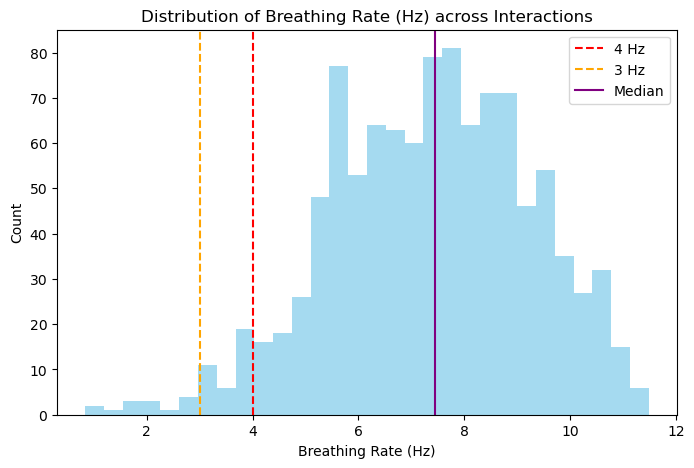

In [90]:
# Inspect the distribution of breathing rate (Hz) for all interactions
resp_rate_col = "breathing_rate_hz"
if resp_rate_col not in master_df.columns:
    raise ValueError(f"Column '{resp_rate_col}' not found in master_df.")

resp_rates = master_df[resp_rate_col].dropna().values

# Basic summary
print(f"Summary stats for {resp_rate_col}:")
print(pd.Series(resp_rates).describe())

# Compute some informative quantiles
quantiles = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
quantile_values = pd.Series(resp_rates).quantile(quantiles)
print("Quantiles:")
for q, v in quantile_values.items():
    print(f"{int(q*100)}th percentile: {v:.2f} Hz")

# Calculate percentage of interactions below certain thresholds
thresholds = [2.5, 3, 3.5, 4, 5, 6, 7, 8]
for thresh in thresholds:
    percent = (resp_rates < thresh).mean() * 100
    print(f"{percent:.1f}% of interactions have Resp Rate < {thresh} Hz")

# Plot the distribution
plt.figure(figsize=(8,5))
plt.hist(resp_rates, bins=30, alpha=0.75, color='skyblue')
plt.title("Distribution of Breathing Rate (Hz) across Interactions")
plt.xlabel("Breathing Rate (Hz)")
plt.ylabel("Count")
plt.axvline(4, color='red', linestyle='--', label='4 Hz')
plt.axvline(3, color='orange', linestyle='--', label='3 Hz')
plt.axvline(np.median(resp_rates), color='purple', linestyle='-', label='Median')
plt.legend()
plt.show()

### End of Feature Matrix Inspection

---

### Visual spot-checks (raw respiration + BM onsets)
Pick a few dominant vs subordinate bouts and inspect whether breath detection looks reliable during active sniffing.

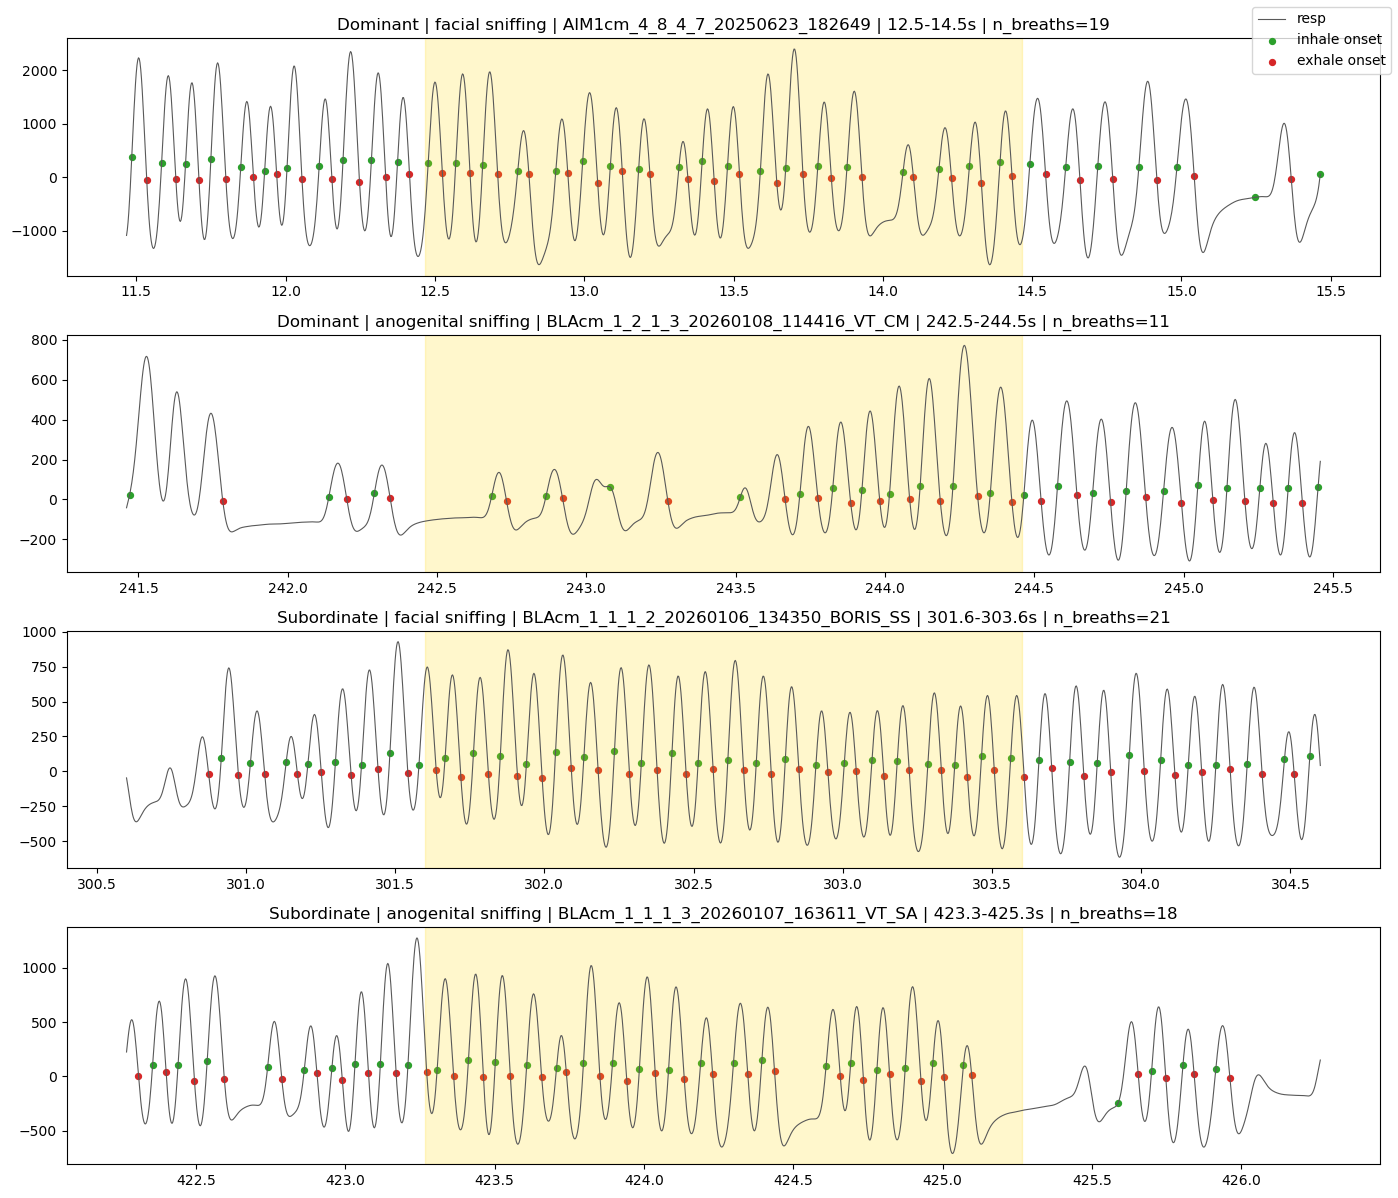

In [91]:
def plot_bout_respiration_spotcheck(df, resp_paths, n_per_rank=2, pad_sec=1.0, random_state=42):
    """Plot raw respiration with BreathMetrics inhale/exhale onsets for sampled bouts."""
    rng = np.random.default_rng(random_state)
    fig, axes = plt.subplots(n_per_rank * 2, 1, figsize=(14, 3 * n_per_rank * 2), sharex=False)
    if len(axes.shape) == 0:
        axes = np.array([axes])

    ax_idx = 0
    for rank in ["Dominant", "Subordinate"]:
        subset = df[(df["Rank"] == rank) & df["h5_path"].notna()] if "h5_path" in df.columns else df[df["Rank"] == rank]
        if subset.empty:
            continue
        picks = subset.sample(n=min(n_per_rank, len(subset)), random_state=rng.integers(1e9)).iterrows()
        for _, row in picks:
            trial = row["Trial"]
            h5_path = row["h5_path"] if "h5_path" in row.index and pd.notna(row["h5_path"]) else resp_paths.get(trial)
            if not h5_path:
                continue
            signal, time, fs, _ = load_rank_resp_signal_interactions(
                h5_path, target_rate=400, prefer_raw=True, verbose=False
            )
            if signal is None:
                continue
            bm = fit_bm_session(signal, fs, data_type="rodentAirflow")
            if bm is None:
                continue

            t0 = max(time[0], row["Start"] - pad_sec)
            t1 = min(time[-1], row["Stop"] + pad_sec)
            mask = (time >= t0) & (time <= t1)
            ax = axes[ax_idx]
            ax.plot(time[mask], signal[mask], color="0.35", lw=0.8, label="resp")

            inhale_t = np.asarray(bm.inhaleOnsets, dtype=float) / fs
            exhale_t = np.asarray(bm.exhaleOnsets, dtype=float) / fs
            inhale_t = inhale_t[(inhale_t >= t0) & (inhale_t <= t1)]
            exhale_t = exhale_t[(exhale_t >= t0) & (exhale_t <= t1)]
            ax.scatter(inhale_t, np.interp(inhale_t, time[mask], signal[mask]), s=18, c="tab:green", label="inhale onset")
            ax.scatter(exhale_t, np.interp(exhale_t, time[mask], signal[mask]), s=18, c="tab:red", label="exhale onset")
            ax.axvspan(row["Start"], row["Stop"], color="gold", alpha=0.2)
            ax.set_title(
                f"{rank} | {row.get('Behavior', '?')} | {trial} | "
                f"{row['Start']:.1f}-{row['Stop']:.1f}s | n_breaths={row.get('n_breaths', '?')}"
            )
            ax_idx += 1

    for j in range(ax_idx, len(axes)):
        axes[j].set_visible(False)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    plt.tight_layout()
    plt.show()


plot_bout_respiration_spotcheck(master_df, resp_paths_interactions, n_per_rank=2)

In [92]:
DATA_DIR = Path(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

master_df.to_pickle(DATA_DIR / "Raw-Breathmatrics-Features-Ran-Interactions")
if "master_df_balanced" in dir():
    master_df_balanced.to_pickle(DATA_DIR / "Raw-Breathmatrics-Features-Rank-balanced-Interactions")
pd.to_pickle(resp_paths_interactions, DATA_DIR / "resp_paths_interactions_rank.pkl")